# 第二組 Project 2

組員：莊雅筑、胡新容、劉芊妤、許鉦偉、陳孝杰、陳柏勳、藍立衡、龍健銘

此專案分成兩部分：

- 【Chapter 1 對 PTT 星宇航空相關文章進行情緒分析】

    - 專案目標：將藉由彙整 PTT（如 Stock、Aviation 板）之社群輿情，拆解大眾對於星宇「精品行銷」與「經營壓力」的真實看法，評估其在高度不確定的環境下，如何維持品牌溢價並平衡利害關係人期待。

- 【Chapter 2 飯店評論分析】

    - 專案目標：探討跨星級飯店的評論分類模型,能否從評論內容預測飯店星級

# Chapter 1 對 PTT 星宇航空相關文章進行情緒分析

- 動機說明
    - 近期星宇動向頻傳，從引發基層熱議的「一個月年終」與 2026 年大規模機隊交付，可見其在資本支出與員工福利間的權衡；而在行銷端，透過邀請蔡依林代言並翻拍經典《布拉格廣場》MV，展現了其插旗歐洲市場的強大品牌野心。然而，面對中東地緣政治引發的燃料供應變數，星宇正逐漸面臨挑戰。

- 困難與解決方法
    - Tarflow 在 PTT 上爬蟲資料有限，因此搭配使用開源[ptt-crawler](https://www.npmjs.com/package/@waynechang65/ptt-crawler)爬蟲，抓取資料。

- 本分析將藉由彙整 PTT（如 Stock、Aviation 板）之社群輿情，拆解大眾對於星宇「精品行銷」與「經營壓力」的真實看法，評估其在高度不確定的環境下，如何維持品牌溢價並平衡利害關係人期待。
------------------------------------------------------------------------------
- 專案進度**從第六週課程開始** 為「文辭和文件分析」，目的為透過TF-IDF, N-gram等方法找出文章以及字詞間的關聯。
以PTT 星宇航空相關文章做為分析資料。

## Chapter 1 大綱
1. 套件說明 
2. 資料前處理
    - 2.1 基本資料介紹
    - 2.2 資料清理
    - 2.3 文章斷詞與整理
3. 找出重要詞彙 - 以TFIDF為例
    - 3.1 計算TF-IDF示範（公式）
    - 3.2 應用於資料集（套件） 
    - 3.3 檢視結果
4.  透過結巴斷詞與N-gram幫助建立斷詞字典
    - 4.1 Bigram
    - 4.2 Bigram視覺化
5.  Pairwise correlation
    - 5.1 和 「機票」, 「行李」 相關性最高的 10 個詞彙
    - 5.2 使用詞彙關係圖畫出以詞頻前60為節點且相關性高於0.3的組合
6. 計算文章相似度
7. 建立Ngram預測模型


## 1. 套件說明

下面列出在本次實作過程中我們所使用到的相關套件，在這個Jupyter Notebook當中我們將會簡單的展示這些套件的使用方式，關於各個套件的進階使用請同學參照其官網的說明。
- pandas: 一個資料分析的函式庫，提供了DataFrame等資料格式，與資料處理的函數。
- numpy: 為科學運算所提供的套件。提供許多數學公式的實作以及高效率的陣列、矩陣運算。
- NLTK: 全名為Natural Language Tool Kit，自然語言處理工具。
- jieba: 中文斷詞套件。
- re: 正規表達式套件。
- math: 數學運算工具。
- collections: 提供額外的數據類型。
- matplotlib: 繪圖工具。
- networkx: 網絡圖建構、繪製工具。
- CountVectorizer, TfidfTransformer: sklearn中計算詞頻與tf-idf的套件。
- numpy.linalg: 矩陣與向量運算套件。

In [1]:
import math
import time
import logging
import re
from collections import Counter, namedtuple
from pprint import pprint
import networkx as nx
import jieba
import jieba.posseg as pseg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager as fm
from nltk import FreqDist, ngrams
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import cross_val_predict, cross_validate, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import make_pipeline
import guidedlda
import gensim
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from gensim.matutils import corpus2csc, corpus2dense
import pyLDAvis
from pyLDAvis import gensim_models

c:\Users\acer\anaconda3\envs\practice\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# 設定圖的中文字體
fm.fontManager.addfont("raw_data/SourceHanSansTW-Regular.otf")
plt.rcParams['font.family'] = 'Source Han Sans TW'
plt.rcParams['font.sans-serif'] = ['Source Han Sans TW']
plt.rcParams['axes.unicode_minus'] = False

## 2. 資料前處理

### 2.1 資料介紹
資料來源：
- 使用開源[ptt-crawler](https://www.npmjs.com/package/@waynechang65/ptt-crawler)爬蟲，抓取PTT 文章。
- 版：「Aviation」、「Stock」
- 標題關鍵字：「星宇」
- 時間: 2025-12-01 ~ 2026-03-18

In [3]:
# 讀取星宇航空的 PTT 文章資料
df = pd.read_csv("raw_data/starlux_dataset.csv")
df.head(3)

,system_id,board,artTitle,artUrl,artDate,rowType,artPoster,artContent
0,0,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,article,unixxxx,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...
1,1,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,comment,Steinadler,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊
2,2,Aviation,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:50,comment,kyuudonut,星宇你應該是看到只能托運一件的 我最近也有注意到


### 2.2 資料初步清理
- 去除特殊字元與標點符號，只留下中文字
- \u4e00-\u9fff 為Unicode中文漢字字符的範圍

In [4]:
clear_df = df.copy()

# 去除一些不需要的欄位
clear_df = clear_df.drop(['artPoster', 'board', 'rowType'], axis=1)
# 只留下中文字
clear_df['sentence'] = clear_df['artContent'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))

clear_df.head(3)

,system_id,artTitle,artUrl,artDate,artContent,sentence
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...
1,1,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的你沒高卡沒哩程需求就是選便宜的啊
2,2,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:50,星宇你應該是看到只能托運一件的 我最近也有注意到,星宇你應該是看到只能托運一件的我最近也有注意到


### 2.3 文章斷詞與整理

In [5]:
# 設定繁體中文詞庫 
jieba.set_dictionary('./dict/dict.txt')

# 新增stopwords 
with open('./dict/stopwords.txt', encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

In [6]:
# 設定斷詞 function
def getToken(row):
    seg_list = jieba.lcut(row)
    seg_list = [w for w in seg_list if w not in stopWords and len(w)>1] # 篩選掉停用字與字元數小於1的詞彙

    return seg_list

In [7]:
data = clear_df.copy()

# 斷詞、去除停用字並將word欄位展開
data['word'] = data.sentence.apply(getToken).explode('word')

data.head(3)

Building prefix dict from c:\Users\acer\Desktop\中山\114下\社群媒體分析\讀書會情緒分析\SMA_G2_PRJ1\dict\dict.txt ...
Loading model from cache C:\Users\acer\AppData\Local\Temp\jieba.ud4559cd62f33f985c3a5821e86eea8ec.cache
Loading model cost 0.534 seconds.
Prefix dict has been built successfully.


,system_id,artTitle,artUrl,artDate,artContent,sentence,word
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,請問
1,1,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的你沒高卡沒哩程需求就是選便宜的啊,新加坡
2,2,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:50,星宇你應該是看到只能托運一件的 我最近也有注意到,星宇你應該是看到只能托運一件的我最近也有注意到,台灣


## 3. 找出重要詞彙 - 以TFIDF為例

TF-IDF 是一種統計方法，可用來評估單詞對於文件的集合的重要程度  
- **TF** (Term Frequency)：某一個詞彙在某一個文件中所出現的頻率  
    - TF = 詞彙在該文件中出現次數 / 該文件中詞彙總數  
- **IDF** (Inverse Document Frequent)：為文件數除以某特定詞彙有被多少文件所提及的數量取log  
    - IDF = log( 總文件數量 / 包含該詞彙的文件數量 ) 

### 3.1 計算TF-IDF示範（公式）

#### 3.1.1 建立示範文件

In [8]:
# 一些短句子示範
doc1 = """中山大學位於高雄柴山地區，附近野生獼猴猖獗，常搶學生食物，甚至抓傷學生，學校推出「與獼猴共存」政策，學生食物若被獼猴搶走，每次可向學校申請上限一百元補償金。
中山大學校園內近日張貼公告，宣導學生食物不外露，勿手拿會吸引獼猴搶奪的食物、提袋、塑膠袋或紙袋等，「如遇到獼猴掠食，先確保自身安全，放棄食物，避免在爭奪過程中受傷」。
校方於二至七月試辦補償措施，只要學生在柴山校區的商店購買食物被獼猴搶食，可到校內店家再次購買餐食，每人每餐補償上限為一百元，不過截至昨天為止，尚未有同學提出申請。"""

doc2 = """國立中山大學為住宿學生提供貼心服務，引進現煮拉麵熱食販賣機，並開放24小時使用「自煮空間」，滿足所有住宿學生的味蕾。
宿舍區同步升級多項軟硬體設施，包含逐步整修換新、定期辦理主題講座、職涯發展分享會、節慶交流活動、增設更多公共空間，並推動「衣服再利用」永續計畫，期能兼顧各種需求，提升住宿品質。
中山大學為方便住宿學生就近覓食，特地引進現煮拉麵熱食販賣機，於今年1月初進駐校園翠亨C棟、雨樹L棟及武嶺武二村聽濤堂前三個宿舍區點，鄰近自習室公共空間，提供大家更多選擇。"""

doc3 = """為了促進第二、第三外語與跨文化學習交流，國立中山大學外文系首辦「在中山說第二外語」語言交換活動，打造練習外語聽說環境，使學生在中山便有機會認識世界、擴展視野，
在全球化下能海納百川，欣賞多國多語言的多元文化。「在中山說第二外語」語言交換活動獲文學院與國際事務處支持推廣，學生參與踴躍，2場次參加人數達70人次，
其中多達半數為非外文系學生，參與外籍生亦來自歐、亞、美洲等不同國家，活動中以德文、法文、西班牙文、日文及韓文使用者為大宗。"""

sample_df = pd.DataFrame({'doc':[1,2,3], 'text': [doc1, doc2, doc3]})

sample_df

,doc,text
0,1,中山大學位於高雄柴山地區，附近野生獼猴猖獗，常搶學生食物，甚至抓傷學生，學校推出「與獼猴共存...
1,2,國立中山大學為住宿學生提供貼心服務，引進現煮拉麵熱食販賣機，並開放24小時使用「自煮空間」，...
2,3,為了促進第二、第三外語與跨文化學習交流，國立中山大學外文系首辦「在中山說第二外語」語言交換活...


資料清理

In [9]:
sample_df['text'] = sample_df['text'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))
sample_df = sample_df.assign(word = sample_df['text'].apply(getToken)).explode('word')

sample_df.head()

,doc,text,word
0,1,中山大學位於高雄柴山地區附近野生獼猴猖獗常搶學生食物甚至抓傷學生學校推出與獼猴共存政策學生食...,中山
0,1,中山大學位於高雄柴山地區附近野生獼猴猖獗常搶學生食物甚至抓傷學生學校推出與獼猴共存政策學生食...,大學
0,1,中山大學位於高雄柴山地區附近野生獼猴猖獗常搶學生食物甚至抓傷學生學校推出與獼猴共存政策學生食...,位於
0,1,中山大學位於高雄柴山地區附近野生獼猴猖獗常搶學生食物甚至抓傷學生學校推出與獼猴共存政策學生食...,高雄
0,1,中山大學位於高雄柴山地區附近野生獼猴猖獗常搶學生食物甚至抓傷學生學校推出與獼猴共存政策學生食...,柴山


#### 3.1.2 計算各文章的總詞彙數

In [10]:
total_words = sample_df.groupby(['doc'], as_index=False).size().rename(columns={'size': 'total'})
total_words.head()

,doc,total
0,1,86
1,2,87
2,3,75


#### 3.1.3 計算各文章的各個詞彙數

In [11]:
word_count = sample_df.groupby(['doc', 'word'], as_index = False).size()

word_count.rename(columns={'size': 'count'}, inplace=True)
word_count.sort_values('count', ascending=False).head()

,doc,word,count
46,1,獼猴,6
60,1,食物,6
19,1,學生,5
135,3,中山,4
69,2,住宿,4


合併需要的資料欄位
- 合併 **每個詞彙在每篇文章中出現的次數** 與 **每篇文章的詞數**

In [12]:
sample_merged = word_count.merge(total_words, on = 'doc', how = 'left')
sample_merged.head(3)

,doc,word,count,total
0,1,一百元,2,86
1,1,七月,1,86
2,1,上限,2,86


#### 3.1.4 計算 TF值

In [13]:
# 計算tf = 詞彙在該文件中出現次數 / 該文件中詞彙總數 
sample_tf_idf = sample_merged.assign(tf = sample_merged["count"] / sample_merged["total"])
sample_tf_idf.head()

,doc,word,count,total,tf
0,1,一百元,2,86,0.023256
1,1,七月,1,86,0.011628
2,1,上限,2,86,0.023256
3,1,中山,2,86,0.023256
4,1,二至,1,86,0.011628


#### 3.1.5 計算 IDF值

In [14]:
# 計算每個詞彙出現在幾篇文章中
idf_df = sample_merged.groupby(['word'], as_index = False).size()

# 合併到之前的df中
sample_tf_idf = sample_tf_idf.merge(idf_df, on = 'word', how = 'left')

sample_tf_idf.head()

,doc,word,count,total,tf,size
0,1,一百元,2,86,0.023256,1
1,1,七月,1,86,0.011628,1
2,1,上限,2,86,0.023256,1
3,1,中山,2,86,0.023256,3
4,1,二至,1,86,0.011628,1


In [15]:
# 計算idf = log( 總文件數量 / 包含該詞彙的文件數量 ) 
sample_tf_idf = sample_tf_idf.assign(idf = sample_tf_idf["size"].apply(lambda size: math.log( len(total_words) / size, 10 ))).drop(["size"], axis=1)

sample_tf_idf.head()

,doc,word,count,total,tf,idf
0,1,一百元,2,86,0.023256,0.477121
1,1,七月,1,86,0.011628,0.477121
2,1,上限,2,86,0.023256,0.477121
3,1,中山,2,86,0.023256,0.000000
4,1,二至,1,86,0.011628,0.477121


#### 3.1.6 計算 TFIDF值

In [16]:
# 計算tf*idf
sample_tf_idf = sample_tf_idf.assign(tf_idf = sample_tf_idf["tf"] * sample_tf_idf["idf"])

sample_tf_idf.sort_values('tf_idf', ascending = False).head(10)

,doc,word,count,total,tf,idf,tf_idf
46,1,獼猴,6,86,0.069767,0.477121,0.033288
60,1,食物,6,86,0.069767,0.477121,0.033288
154,3,外語,4,75,0.053333,0.477121,0.025446
69,2,住宿,4,87,0.045977,0.477121,0.021937
178,3,第二,3,75,0.040000,0.477121,0.019085
185,3,語言,3,75,0.040000,0.477121,0.019085
110,2,空間,3,87,0.034483,0.477121,0.016452
152,3,外文系,2,75,0.026667,0.477121,0.012723
137,3,交換,2,75,0.026667,0.477121,0.012723
147,3,參與,2,75,0.026667,0.477121,0.012723


In [17]:
# 選出每個文件，tf-idf值最大的前三個詞
group = sample_tf_idf.groupby("doc").apply(lambda x : x.nlargest(3, "tf_idf"))
group

C:\Users\acer\AppData\Local\Temp\ipykernel_15256\1751358733.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group = sample_tf_idf.groupby("doc").apply(lambda x : x.nlargest(3, "tf_idf"))


doc word  count  total        tf       idf    tf_idf
doc                                                          
1   46     1   獼猴      6     86  0.069767  0.477121  0.033288
    60     1   食物      6     86  0.069767  0.477121  0.033288
    0      1  一百元      2     86  0.023256  0.477121  0.011096
2   69     2   住宿      4     87  0.045977  0.477121  0.021937
    110    2   空間      3     87  0.034483  0.477121  0.016452
    71     2   公共      2     87  0.022989  0.477121  0.010968
3   154    3   外語      4     75  0.053333  0.477121  0.025446
    178    3   第二      3     75  0.040000  0.477121  0.019085
    185    3   語言      3     75  0.040000  0.477121  0.019085

### 3.2 應用於資料集（套件）

除了直接用公式計算，也可以使用sklearn中計算詞頻與tf-idf的套件。

DTM 介紹
- Document term matrix (DTM)，是一種用於自然語言處理的數學矩陣，描述了在一組文件中各個詞彙出現的頻率。   
- DTM 中的每一行代表一個文件(Document)，每一列代表一個詞彙(Term)，每一格的值表示該詞彙在該文件中的出現次數。

舉例來說，若有三個文件其內容如下：
- 文件1：「今天天氣很好」
- 文件2：「今天是星期五」
- 文件3：「昨天是星期四而且天氣很好」

而這些文件斷完詞後的結果可能為：
- 文件1：「今天／天氣／很／好」
- 文件2：「今天／是／星期五」
- 文件3：「昨天／是／星期四／而且／天氣／很／好」
 

In [18]:
starlux_df = data.copy()
starlux_df.head(3)    

,system_id,artTitle,artUrl,artDate,artContent,sentence,word
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,請問
1,1,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的你沒高卡沒哩程需求就是選便宜的啊,新加坡
2,2,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:50,星宇你應該是看到只能托運一件的 我最近也有注意到,星宇你應該是看到只能托運一件的我最近也有注意到,台灣


In [19]:
# 保留需要的欄位
starlux_df = starlux_df.loc[:,["system_id", "sentence"]]

# 改成使用空格連接斷完的詞
starlux_df['word'] = starlux_df.sentence.apply(getToken).map(' '.join)

starlux_df.head()

,system_id,sentence,word
0,0,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,請問 新加坡 台灣 星宇星 加坡 長榮 票價 星宇 便宜 明白 那麼多 選星宇 累計 里程 ...
1,1,這有什麼好糾結的你沒高卡沒哩程需求就是選便宜的啊,這有 糾結 沒高卡 哩程 需求 便宜
2,2,星宇你應該是看到只能托運一件的我最近也有注意到,星宇 看到 托運 一件 最近 注意到
3,3,金城武都選長榮你參考,金城武 長榮 參考
4,4,非哩程卡客就挑便宜的啊為什麼便宜可能剛好低價票還有或設定促銷票給你看到,哩程 卡客 便宜 便宜 低價票 設定 促銷 票給 看到


每一行代表一個文件(Document)，每一列代表一個詞彙(Term)，每一格的值表示該詞彙在該文件中的出現次數。

In [20]:
# Bag of Word
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(starlux_df["word"])
vocabulary = vectorizer.get_feature_names_out()

# 轉成 dataframe
DTM_df = pd.DataFrame(columns = vocabulary, data = X.toarray())
DTM_df

,一三四六,一下,一二嘛,一人,一代,一件,一份,一位,一併,一個點,...,鼎立,鼓勵,鼓吹,鼓舞,鼻子,鼻酸,齊發,龍眼,龍頭,龐大
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4078,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4079,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4080,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4081,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


計算TFIDF

In [21]:
transformer = TfidfTransformer()  
# 將詞頻矩陣X統計成TF-IDF值
tfidf = transformer.fit_transform(X)  

# 轉成dataframe
TFIDF_df = pd.DataFrame(columns = vocabulary, data = tfidf.toarray())

TFIDF_df

,一三四六,一下,一二嘛,一人,一代,一件,一份,一位,一併,一個點,...,鼎立,鼓勵,鼓吹,鼓舞,鼻子,鼻酸,齊發,龍眼,龍頭,龐大
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.508782,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4078,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4079,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4080,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4081,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 3.3 檢視結果   
根據tfidf值來挑出重要詞彙的方法有許多種，以下舉兩個方法當範例：
- 取每一個字詞在所有文件裡的TF-IDF平均值
- 取每份文件裡TF-IDF值最大的前10個字詞當為常用字詞，再取每一個字詞在常用字詞中出現頻率

#### 3.3.1 方法1： 取每一個字詞在所有文件裡的TF-IDF平均值

In [22]:
starlux_tfidf = TFIDF_df.mean().to_frame().reset_index() ## !!
starlux_tfidf.columns = ["word", "avg"]

starlux_tfidf.sort_values('avg', ascending = False).head(10)

,word,avg
4771,星宇,0.021940
1294,公司,0.016643
3412,年終,0.016298
2122,員工,0.016100
9921,飛機,0.012984
9434,長榮,0.012467
7672,華航,0.012389
7571,航空,0.011010
1936,台中,0.010086
7246,罷工,0.009826


#### 3.3.2 方法2： 取每份文件裡TF-IDF值最大的前10個字詞當為常用字詞，再取每一個字詞在常用字詞中出現頻率

In [23]:
#toptens = starlux_tfidf.copy()
toptens = TFIDF_df.copy()
toptens.insert(0, 'doc_id', toptens.index+1)

toptens

,doc_id,一三四六,一下,一二嘛,一人,一代,一件,一份,一位,一併,...,鼎立,鼓勵,鼓吹,鼓舞,鼻子,鼻酸,齊發,龍眼,龍頭,龐大
0,1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0.0,0.0,0.0,0.0,0.0,0.508782,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4078,4079,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4079,4080,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4080,4081,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4081,4082,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
toptens = toptens.melt(id_vars = "doc_id", var_name = "word", value_name = 'tfidf')
toptens

,doc_id,word,tfidf
0,1,一三四六,0.0
1,2,一三四六,0.0
2,3,一三四六,0.0
3,4,一三四六,0.0
4,5,一三四六,0.0
...,...,...,...
41618014,4079,龐大,0.0
41618015,4080,龐大,0.0
41618016,4081,龐大,0.0
41618017,4082,龐大,0.0


以下表格是結果: nlargest() 會回傳指定列中最大的前x個值所對應的資料

In [25]:
#把 tfidf 這個欄位裡面的所有東西，都轉換成「數字 (Numeric) 型態」。
toptens['tfidf'] = pd.to_numeric(toptens['tfidf'], errors='coerce')

#過濾掉0分的詞(字詞沒有出現的)，只保留 tfidf 分數大於 0 的資料
toptens = toptens[toptens['tfidf'] > 0]
(
    # 從每篇文章挑選出tf-idf最大的前十個詞
    toptens.groupby("doc_id").apply(lambda x : x.nlargest(10, "tfidf"), include_groups=False).reset_index(drop=True)
   
    # 計算每個詞被選中的次數
    .groupby(['word'],as_index=False).size()

).sort_values('size', ascending=False).head(10) # 排序看前十名

,word,size
3683,星宇,313
2627,年終,204
1635,員工,203
1010,公司,202
7547,飛機,158
5861,華航,146
7188,長榮,145
5792,航空,135
1497,台中,118
5530,罷工,101


## 4. 透過結巴斷詞與N-gram幫助建立斷詞字典
N-gram 指文本中連續出現的n個語詞。   
透過N-gram我們可以找出有哪些詞彙較常一起出現，檢查是否需要加入自定義字典中。   

N-gram範例：

In [26]:
token = jieba.lcut("中山資管全國第一")
token

['中山', '資管', '全國', '第一']

In [27]:
# 利用nltk的ngrams()
# Bigram
bigram  = ngrams(token, 2)
list(bigram)

[('中山', '資管'), ('資管', '全國'), ('全國', '第一')]

In [28]:
# Trigram
trigram  = ngrams(token, 3)
list(trigram)

[('中山', '資管', '全國'), ('資管', '全國', '第一')]

### 4.1 Bigram

In [29]:
# 設定 ngram 斷詞 function
def ngram_getToken(row, n):
    # 進行斷詞
    seg_list = jieba.lcut(row)

    # 篩選掉停用字與字元數小於1的詞彙
    seg_list = [w for w in seg_list if w not in stopWords and len(w)>1]

    # ngram斷詞
    seg_list = ngrams(seg_list, n)
    seg_list = [" ".join(w) for w in list(seg_list)]
    
    return seg_list

In [30]:
starlux_bigram = data.copy()

starlux_bigram["word"] = starlux_bigram['sentence'].apply(lambda row: ngram_getToken(row, 2))
starlux_bigram = starlux_bigram.explode('word')

starlux_bigram.head(3)

,system_id,artTitle,artUrl,artDate,artContent,sentence,word
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,請問 新加坡
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,新加坡 台灣
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,台灣 星宇星


#### 4.1.1 統計最常出現的bigram組合

In [31]:
# 計算每個組合出現的次數
starlux_bigram_count = starlux_bigram['word'].value_counts().reset_index()

starlux_bigram_count.sort_values('count', ascending=False).head(10)

,word,count
0,星宇 航空,206
1,航空 公司,83
2,年終 獎金,68
3,長榮 華航,36
4,華航 長榮,30
5,星宇 員工,27
6,精品 航空,24
7,員工 年終,24
8,新創 公司,18
9,原文 連結,18


從上面的 bigram 和 trigram 的結果中，我們發現"星宇 航空"、"航空 公司"等詞可以組合在一起，所以我們增加自定義字典來幫助斷詞能更準確。  
我們將詞彙整理好存在 dict 文件夾中的 user_dict 中。

In [32]:
# 載入自定義辭典：一個詞一行，每行分詞語、詞頻(可省)、詞性(可省)
jieba.load_userdict("./dict/user_dict.txt")

In [33]:
# 剛才的斷詞結果沒有使用新增的辭典，因此我們重新進行斷詞
data2 = data.copy()
data2['word'] = data2.sentence.apply(getToken)
data2 = data2.explode('word')

data2.head(3)

,system_id,artTitle,artUrl,artDate,artContent,sentence,word
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,請問
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,新加坡
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,台灣


### 4.2 Bigram視覺化

更新斷詞字典後重新進行bigram斷詞

In [34]:
bigramfdist = data.copy()

bigramfdist["word"] = bigramfdist['sentence'].apply(lambda row: ngram_getToken(row, 2))
bigramfdist = bigramfdist.explode('word')

bigramfdist.head(3)

,system_id,artTitle,artUrl,artDate,artContent,sentence,word
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,請問 新加坡
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,新加坡 台灣
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,台灣 星宇星


重新進行斷詞後，再次取得bigram，便得到以下輸出

In [35]:
bigramfdist['word'] = bigramfdist['word'].astype(str)

# 使用FreqDist 取得 bigram 斷詞 與 bigram出現頻率
bigramfdist = FreqDist(bigramfdist['word'].apply(lambda x: tuple(x.split(' '))))
bigramfdist.most_common(5)


[(('nan',), 437),
 (('長榮', '華航'), 36),
 (('華航', '長榮'), 30),
 (('星宇', '員工'), 27),
 (('精品', '航空'), 24)]

除了利用N-gram來幫助建立斷詞字典，N-gram也能幫助我們發現詞與詞之間的連貫關係。

接下來針對重新斷詞後的bigram出現頻率最高的前50對進行「視覺化」，觀察文章的關鍵詞

In [36]:
# 建立bigram和count的dictionary
# 這裡取最多的前50項
d = {k:v for k,v in bigramfdist.most_common(50)}

In [37]:
# Create network plot 
G = nx.Graph()

# 建立 nodes 間的連結
for k, v in [d][0].items():
    # ==========================================
    # 關鍵：檢查 k 裡面是不是真的有兩個詞！
    # 只有長度大於等於 2 的組合，才允許建立連線
    # ==========================================
    if len(k) >= 2:
        G.add_edge(k[0], k[1], weight=v) # nodes：詞彙，weight：組合出現頻率
    else:
        # 如果只有一個詞，我們就印出來看看是誰在搗亂，然後跳過它
        print(f"發現落單的詞彙，已跳過：{k}")
        
# 取得調整edge權重
weights = [w[2]['weight']*0.05 for w in G.edges(data=True)]

print(f"網路圖連線成功！目前圖中有 {G.number_of_nodes()} 個節點，與 {G.number_of_edges()} 條連線。")

發現落單的詞彙，已跳過：('nan',)
網路圖連線成功！目前圖中有 60 個節點，與 47 條連線。


c:\Users\acer\anaconda3\envs\practice\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
c:\Users\acer\anaconda3\envs\practice\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
c:\Users\acer\anaconda3\envs\practice\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


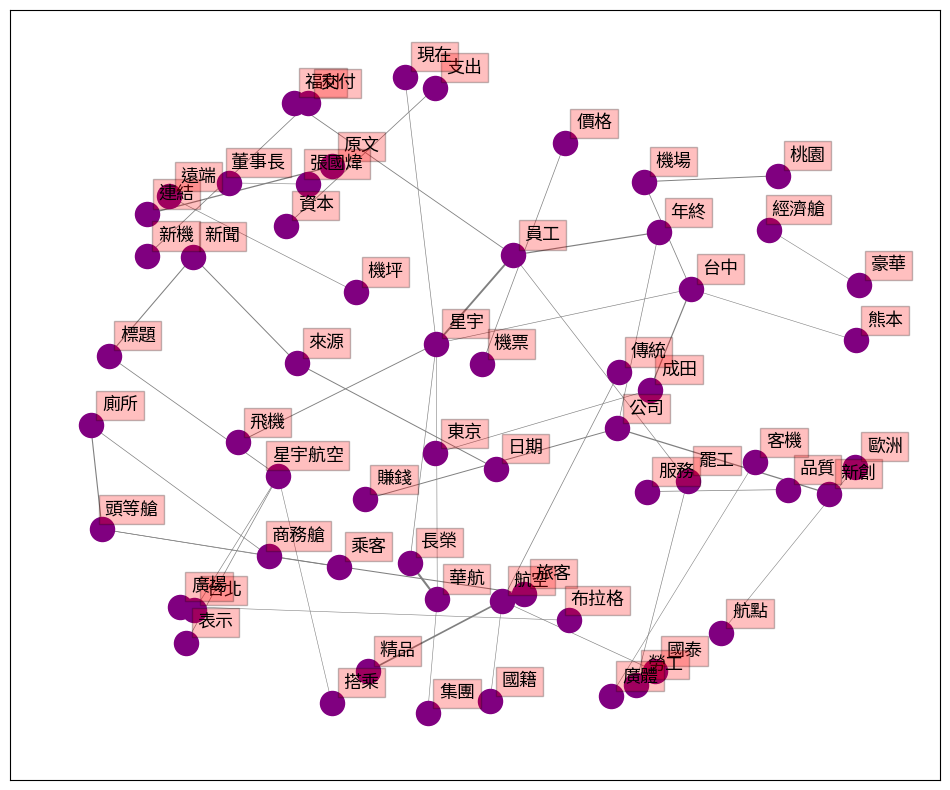

In [38]:
fig, ax = plt.subplots(figsize=(12, 10))

pos = nx.spring_layout(G, k=1.5)

# networks
nx.draw_networkx(G, pos,
                 font_size=16,
                 width=weights,
                 edge_color='grey',
                 node_color='purple',
                 with_labels = False,
                 ax=ax)

# 增加 labels
for key, value in pos.items():
    x, y = value[0]+.07, value[1]+.045
    ax.text(x, y,
            s=key,
            bbox=dict(facecolor='red', alpha=0.25),
            horizontalalignment='center', fontsize=13)
    
plt.show()

## 5. Pairwise correlation

計算兩個詞彙間的相關性 Pearson correlation

In [39]:
data_cor = data.copy()

# 需要改成使用空格連接斷好的詞
data_cor['word'] = data_cor.sentence.apply(getToken).map(' '.join)
data_cor.head(3)

,system_id,artTitle,artUrl,artDate,artContent,sentence,word
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,請問 新加坡 台灣 星宇星 加坡 長榮 票價 星宇 便宜 明白 那麼多 選星宇 累計 里程 ...
1,1,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的你沒高卡沒哩程需求就是選便宜的啊,這有 糾結 沒高卡 哩程 需求 便宜
2,2,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:50,星宇你應該是看到只能托運一件的 我最近也有注意到,星宇你應該是看到只能托運一件的我最近也有注意到,星宇 看到 托運 一件 最近 注意到


篩選至少出現在5篇文章以上且詞頻前500的詞彙，避免表格太大

In [40]:
# Bag of Word
vectorizer = CountVectorizer(min_df = 5, max_features = 500)
X = vectorizer.fit_transform(data_cor["word"])
vocabulary = vectorizer.get_feature_names_out()

# 轉成dataframe
DTM_df = pd.DataFrame(columns = vocabulary, data = X.toarray())
DTM_df

,一下,一堆,一天,一年,一架,一次,一直,一間,一點,三家,...,飛行,餐點,首架,首爾,首航,香港,香蕉,體驗,高雄,鳳凰城
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4078,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4079,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4080,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4081,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


計算詞之間的相關係數

In [41]:
corr_matrix = np.corrcoef(DTM_df.T)

# 轉成dataframe
Cor_df = pd.DataFrame(corr_matrix, index = DTM_df.columns, columns = DTM_df.columns)

Cor_df.insert(0, 'word1', Cor_df.columns)
Cor_df.reset_index(inplace = True, drop = True)

Cor_df

,word1,一下,一堆,一天,一年,一架,一次,一直,一間,一點,...,飛行,餐點,首架,首爾,首航,香港,香蕉,體驗,高雄,鳳凰城
0,一下,1.000000,0.030614,0.083635,-0.009305,0.053741,0.014719,0.042796,0.052901,0.070924,...,0.073443,0.067741,-0.004376,0.060647,-0.006319,0.071885,-0.006231,0.049048,0.007563,-0.003289
1,一堆,0.030614,1.000000,-0.008217,-0.012643,-0.008217,0.026778,0.016229,-0.009396,-0.006011,...,0.016848,0.016970,-0.005946,-0.009767,-0.008586,-0.008711,-0.008466,-0.008405,0.016771,-0.004469
2,一天,0.083635,-0.008217,1.000000,-0.004630,0.059679,-0.004142,0.022807,0.059276,0.022874,...,0.030237,0.058622,-0.002177,0.043840,-0.003144,-0.003190,-0.003100,0.054835,0.039077,-0.001636
3,一年,-0.009305,-0.012643,-0.004630,1.000000,-0.004630,0.075800,0.073626,-0.005294,0.039940,...,0.109536,0.204265,0.017823,-0.005503,0.022520,0.057137,-0.004770,0.192230,0.015131,0.004419
4,一架,0.053741,-0.008217,0.059679,-0.004630,1.000000,0.044180,-0.006935,-0.003441,0.022874,...,0.064070,0.027998,-0.002177,-0.003577,-0.003144,0.106267,-0.003100,-0.003078,0.039077,-0.001636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,香港,0.071885,-0.008711,-0.003190,0.057137,0.106267,0.079982,0.070546,-0.003648,0.044351,...,0.143875,0.184363,-0.002308,-0.003792,0.123075,1.000000,-0.003287,0.097857,0.012553,0.222617
496,香蕉,-0.006231,-0.008466,-0.003100,-0.004770,-0.003100,-0.004268,-0.007144,-0.003545,-0.006625,...,-0.003705,-0.002704,-0.002243,-0.003685,-0.003239,-0.003287,1.000000,-0.003171,-0.007442,-0.001686
497,體驗,0.049048,-0.008405,0.054835,0.192230,-0.003078,0.040404,0.144027,0.141329,0.034031,...,0.527672,0.548981,-0.002227,0.040147,0.041371,0.097857,-0.003171,1.000000,0.003305,0.003979
498,高雄,0.007563,0.016771,0.039077,0.015131,0.039077,-0.009943,0.071221,-0.008259,-0.004615,...,-0.008632,-0.006301,-0.005226,-0.008586,0.010276,0.012553,-0.007442,0.003305,1.000000,0.009629


In [42]:
word_cor_df = Cor_df.melt(id_vars = 'word1', var_name = 'word2', value_name = 'cor')

# 去除兩個詞相同的情況
word_cor_df = word_cor_df[word_cor_df["word1"] != word_cor_df["word2"]]

word_cor_df.sort_values('cor', ascending=False).head(10)

,word1,word2,cor
230670,引述,銘言,1.000000
85461,銘言,引述,1.000000
11971,陳漢典,乘客,0.917696
235523,乘客,陳漢典,0.917696
156852,網友,發文,0.912955
176313,發文,網友,0.912955
165915,調查,程序,0.901701
207831,程序,調查,0.901701
139915,調查,民航局,0.889861
207779,民航局,調查,0.889861


### 5.1 和 「機票」, 「行李」 相關性最高的 10 個詞彙

In [43]:
ticket_sum = word_cor_df[(word_cor_df["word1"] == "機票")].sort_values(by = ['cor'], ascending = False).head(10)
baggage_sum = word_cor_df[(word_cor_df["word1"] == "行李")].sort_values(by = ['cor'], ascending = False).head(10)

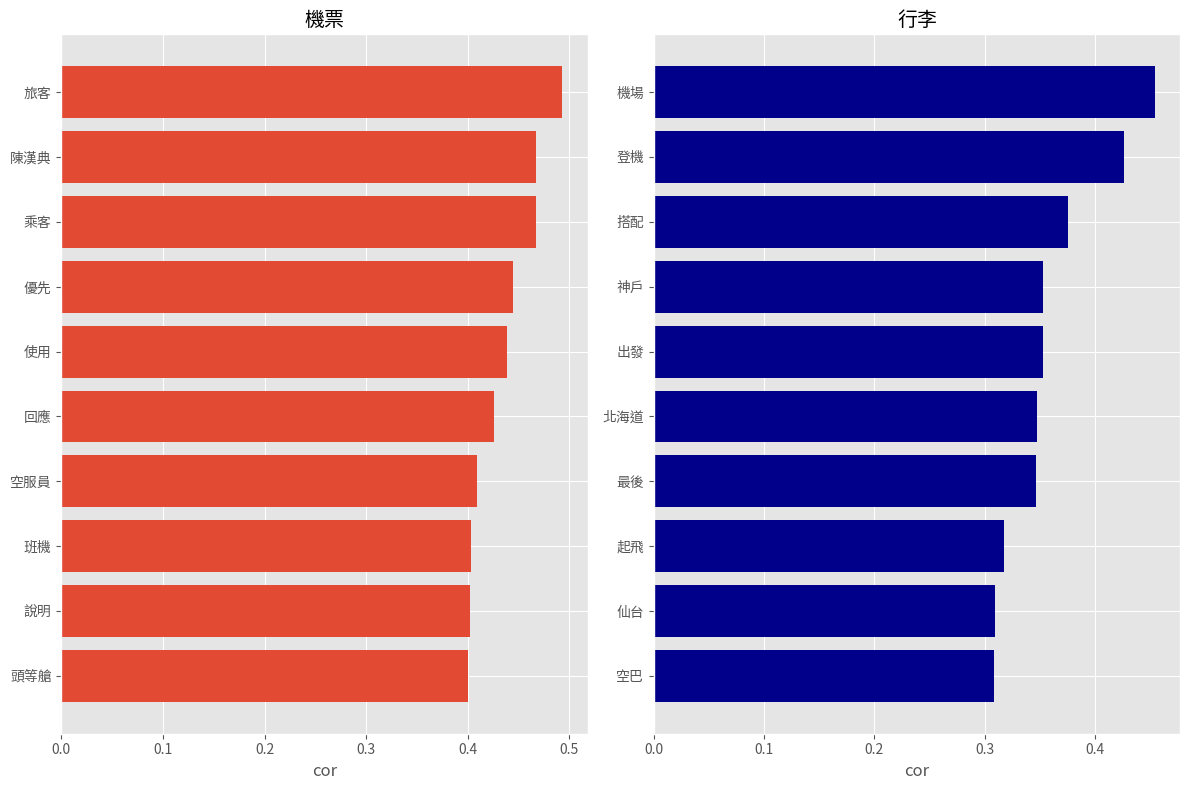

In [44]:
plt.figure(figsize=(12,8))   # 顯示圖框架大小 (寬,高)
plt.style.use("ggplot")     # 使用ggplot主題樣式

plt.subplot(121)
plt.title('機票')
plt.xlabel('cor')
plt.barh(ticket_sum['word2'],ticket_sum['cor'])
plt.gca().invert_yaxis()

plt.subplot(122)
plt.title('行李')
plt.xlabel('cor')
plt.barh(baggage_sum['word2'],baggage_sum['cor'],color="darkblue")
plt.gca().invert_yaxis()
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']

plt.tight_layout()
plt.show()

### 5.2 使用詞彙關係圖畫出以詞頻前60為節點且相關性高於0.3的組合

In [45]:
# 透過DTM找出詞頻前60高的詞彙
most_freq_df = DTM_df.sum().sort_values(ascending=False).head(60).reset_index().rename(columns={'index':'word', 0:'count'})

most_freq_word = most_freq_df['word'].tolist()

In [46]:
# 保留存在詞頻前60高之詞彙的組合
filtered_df = word_cor_df[(word_cor_df['word1'].isin(most_freq_word)) & (word_cor_df['word2'].isin(most_freq_word))]

# 篩選出相關係數大於0.3的組合
filtered_df = filtered_df[filtered_df['cor'] > 0.3]
filtered_df.reset_index(inplace=True, drop=True)
filtered_df

,word1,word2,cor
0,台中,今年,0.318705
1,台北,今年,0.337721
2,員工,今年,0.382297
3,年終獎金,今年,0.479827
4,張國煒,今年,0.348302
...,...,...,...
217,年終獎金,飛機,0.344977
218,成本,飛機,0.467979
219,星宇,飛機,0.538802
220,星宇航空,飛機,0.305673


In [47]:
# Create network plot
g = nx.Graph()

# 建立 nodes 間的連結
for i in range(len(filtered_df)):
    g.add_edge(filtered_df["word1"][i], filtered_df["word2"][i], weight=filtered_df["cor"][i])

# 取得edge權重
weights = [w[2]['weight']*5 for w in  g.edges(data=True)]

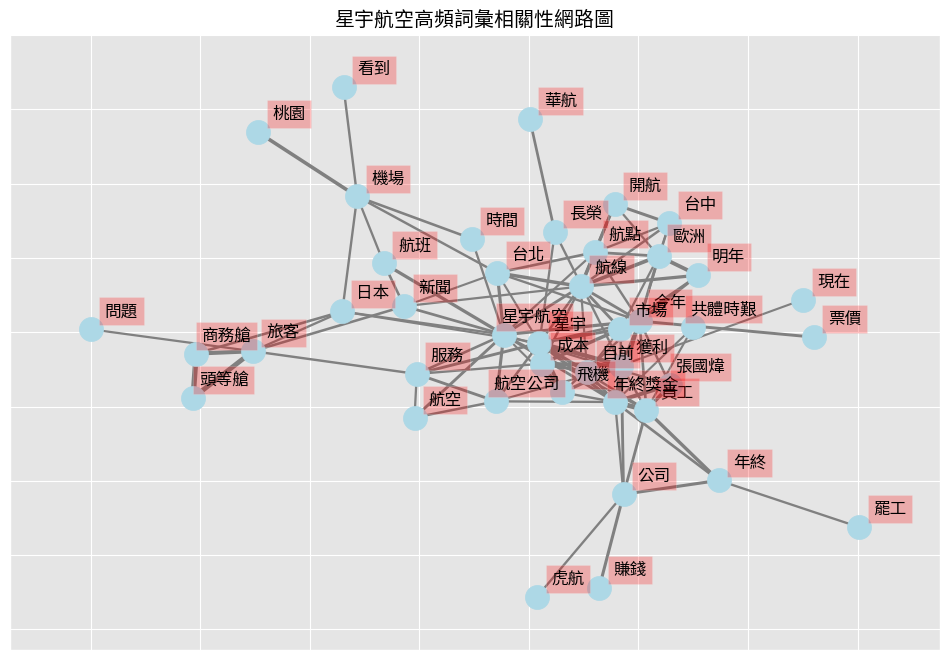

In [48]:
fig, ax = plt.subplots(figsize=(12, 8))

pos = nx.spring_layout(g, k=0.3)

# networks
nx.draw_networkx(g, pos,
                 font_size=16,
                 width=weights,
                 edge_color='grey',
                 node_color='lightblue',
                 with_labels = False,
                 ax=ax)

# 增加 labels
for key, value in pos.items():
    x, y = value[0]+.07, value[1]+.045
    ax.text(x, y,
            s=key,
            bbox=dict(facecolor='red', alpha=0.25),
            horizontalalignment='center', fontsize=12)

plt.title("星宇航空高頻詞彙相關性網路圖")
plt.show()

從圖中可以清楚看出具有高度相連關係的詞彙。

## 6. 計算文章相似度

以TF-IDF的結果當作文章的向量，計算 Cosine Similarity 找出相似的文章

In [49]:
data_cos = data_cor.copy()
data_cos.head(3)

,system_id,artTitle,artUrl,artDate,artContent,sentence,word
0,0,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:55,請問新加坡飛台灣\n\n星宇 星加坡 長榮會怎麼選呢?\n\n看票價星宇是便宜蠻多的 不明白...,請問新加坡飛台灣星宇星加坡長榮會怎麼選呢看票價星宇是便宜蠻多的不明白怎麼差那麼多但是如果選星...,請問 新加坡 台灣 星宇星 加坡 長榮 票價 星宇 便宜 明白 那麼多 選星宇 累計 里程 ...
1,1,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 15:56,這有什麼好糾結的？你沒高卡沒哩程需求就是選便宜的啊,這有什麼好糾結的你沒高卡沒哩程需求就是選便宜的啊,這有 糾結 沒高卡 哩程 需求 便宜
2,2,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...,2026/03/14 16:50,星宇你應該是看到只能托運一件的 我最近也有注意到,星宇你應該是看到只能托運一件的我最近也有注意到,星宇 看到 托運 一件 最近 注意到


In [50]:
transformer = TfidfTransformer()
print(transformer)
# 將詞頻矩陣X統計成TF-IDF值
tfidf = transformer.fit_transform(X)

# 轉成dataframe
TFIDF_df = pd.DataFrame(columns = vocabulary, data = tfidf.toarray())
TFIDF_df

TfidfTransformer()


,一下,一堆,一天,一年,一架,一次,一直,一間,一點,三家,...,飛行,餐點,首架,首爾,首航,香港,香蕉,體驗,高雄,鳳凰城
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4079,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4080,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4081,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


計算文章間的cosine similarity

In [51]:
cosine_matrix = cosine_similarity(tfidf.toarray(), tfidf.toarray())

檢視與第一篇文章相似的文章

In [52]:
cos_df = pd.DataFrame(cosine_matrix[0], columns = ['cos_similarity'])
cos_df

,cos_similarity
0,1.000000
1,0.180031
2,0.061613
3,0.401714
4,0.213812
...,...
4078,0.000000
4079,0.000000
4080,0.000000
4081,0.000000


與第一篇相似的文章有以下幾篇:

In [53]:
cos_df = cos_df.merge(data_cos, how = 'left', left_index=True, right_index=True)
cos_df.loc[:,["cos_similarity", "artTitle", "artUrl"]].sort_values(by=['cos_similarity'], ascending=False).head(10)

,cos_similarity,artTitle,artUrl
0,1.000000,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...
3477,0.434224,Re: [新聞] 星宇員工不滿年終僅1個月 張國煒「聽到了,https://www.ptt.cc/bbs/Stock/M.1770952324.A.86...
1885,0.415106,[新聞] 星宇張國煒：今年14架新機加入 壓力大,https://www.ptt.cc/bbs/Aviation/M.1767674291.A...
3090,0.401714,Re: [新聞] 星宇員工不滿年終僅1個月 張國煒「聽到了,https://www.ptt.cc/bbs/Stock/M.1770962937.A.05...
2101,0.401714,[新聞] 星宇公布年終1個月、整體調薪3% 有員工抱,https://www.ptt.cc/bbs/Aviation/M.1767066330.A...
3797,0.401714,Re: [新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767147201.A.1F...
3794,0.401714,Re: [新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767147201.A.1F...
3783,0.401714,Re: [新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767147201.A.1F...
2466,0.401714,[新聞] 星宇航空將推宮古島航線 明年底增飛歐洲,https://www.ptt.cc/bbs/Aviation/M.1765981776.A...
1970,0.401714,[新聞] 星宇贊助跨年卻只發1個月年終 薪資平台：,https://www.ptt.cc/bbs/Aviation/M.1767418538.A...


檢視與第14篇文章相似的文章

In [54]:
cos_df_14 = pd.DataFrame(cosine_matrix[0], columns=['cos_similarity'])

cos_df_14 = cos_df_14.merge(data_cos, how = 'left', left_index=True, right_index=True)
cos_df_14.loc[:,["cos_similarity", "artTitle", "artUrl"]].sort_values(by=['cos_similarity'], ascending=False).head(10)

,cos_similarity,artTitle,artUrl
0,1.000000,[問題] 星宇 華航 新加坡 航空選擇,https://www.ptt.cc/bbs/Aviation/M.1773474933.A...
3477,0.434224,Re: [新聞] 星宇員工不滿年終僅1個月 張國煒「聽到了,https://www.ptt.cc/bbs/Stock/M.1770952324.A.86...
1885,0.415106,[新聞] 星宇張國煒：今年14架新機加入 壓力大,https://www.ptt.cc/bbs/Aviation/M.1767674291.A...
3090,0.401714,Re: [新聞] 星宇員工不滿年終僅1個月 張國煒「聽到了,https://www.ptt.cc/bbs/Stock/M.1770962937.A.05...
2101,0.401714,[新聞] 星宇公布年終1個月、整體調薪3% 有員工抱,https://www.ptt.cc/bbs/Aviation/M.1767066330.A...
3797,0.401714,Re: [新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767147201.A.1F...
3794,0.401714,Re: [新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767147201.A.1F...
3783,0.401714,Re: [新聞] 星宇宣布年終1個月、調薪3% 員工怨太少,https://www.ptt.cc/bbs/Stock/M.1767147201.A.1F...
2466,0.401714,[新聞] 星宇航空將推宮古島航線 明年底增飛歐洲,https://www.ptt.cc/bbs/Aviation/M.1765981776.A...
1970,0.401714,[新聞] 星宇贊助跨年卻只發1個月年終 薪資平台：,https://www.ptt.cc/bbs/Aviation/M.1767418538.A...


## 7. 建立Ngram預測模型

使用我們的抓取的 PTT 星宇航空資料集

In [55]:
data_ngram = data.copy()
sen_tokens = data_ngram.sentence.apply(getToken).tolist()

In [56]:
def ngram(documents, N=2):
    ngram_prediction = dict()
    total_grams = list()
    words = list()
    Word = namedtuple('Word', ['word', 'prob'])

    for doc in documents:
        # 加上開頭和結尾 tag
        split_words = ['<s>'] + list(doc) + ['</s>']
        # 計算分子
        [total_grams.append(tuple(split_words[i:i+N])) for i in range(len(split_words)-N+1)]
        # 計算分母
        [words.append(tuple(split_words[i:i+N-1])) for i in range(len(split_words)-N+2)]

    total_word_counter = Counter(total_grams)
    word_counter = Counter(words)

    for key in total_word_counter:
        word = ''.join(key[:N-1])
        if word not in ngram_prediction:
            ngram_prediction.update({word: set()})

        next_word_prob = total_word_counter[key]/word_counter[key[:N-1]] #P(B|A)
        w = Word(key[-1], '{:.3g}'.format(next_word_prob))
        ngram_prediction[word].add(w)

    return ngram_prediction

In [57]:
# Bigram預測模型為例
bi_prediction = ngram(sen_tokens, N=2)

預測"星宇"下一個出現的詞

In [58]:
text = '星宇'
next_words = list(bi_prediction[text])
next_words.sort(key = lambda s: s[1], reverse = True)
for next_word in next_words[:5]:
    print('next word: {}, probability: {}'.format(next_word.word, next_word.prob))

next word: 員工, probability: 0.0459
next word: </s>, probability: 0.0374
next word: 飛機, probability: 0.0221
next word: 現在, probability: 0.0153
next word: 台中, probability: 0.0153


In [59]:
text = '張國煒'
next_words = list(bi_prediction[text])
next_words.sort(key = lambda s: s[1], reverse = True)
for next_word in next_words[:5]:
    print('next word: {}, probability: {}'.format(next_word.word, next_word.prob))

next word: 吃定, probability: 0.058
next word: 經營, probability: 0.0435
next word: 心情, probability: 0.029
next word: 老本, probability: 0.029
next word: 老闆, probability: 0.029


# Chapter 2 飯店評論分析

- 專案目標：探討跨星級飯店的評論分類模型,能否從評論內容預測飯店星級
- 訓練/測試資料：以高雄 5 星、4 星、3 星、2 星飯店的 TripAdvisor 評論 (7:3 切分)
    - 四家飯店分別為各星級中評論數最多的一家

- 重點：
    - 模型能否從評論內容 (`content`) 正確分類出飯店星級 (`hotel_class`)
    - 不同星級飯店在評論內容與用字風格上的差異
    - 分析分類準確度與表現落差背後的原因

## Chapter 2 大綱
1. 文字前處理
    - 1.1 清理
    - 2.2 段詞
    - 2.3 資料及基本檢視
2. 分類模型的訓練流程
    - 2.1 根據7:3比例切分資料集
    - 2.2 將文章轉為DTM
    - 2.3 套入正式的資料集
    - 2.4 模型評估
    - 2.5 TF-IDF
    - 2.6 CV
3. 比較不同模型效果 (Decision Tree、Logistic Regression、SVM、Random Forest)
4. 分析可解釋模型的結果
    - 4.1 各字詞特徵的迴歸係數
5. 用訓練好的分類器檢視各星級的詳細分類表現
6. 主題模型
    - 6.1 資料前處理
    - 6.2 Lexicon-based主題模型
    - 6.3 LDA主題模型
    - 6.4 視覺化呈現
    - 6.5 GuidedLDA
    - 6.6 主題分佈的應用，搭配其他文章資訊 (LDA)

## 1. 文字前處理
本次分析使用四個星級飯店的 TripAdvisor 評論資料(`5star.xlsx`、`4star.xlsx`、`3star.xlsx`、`2star.xlsx`)。
- 資料內容：各星級代表的飯店中評論數最多的那一家
- 原始欄位：reviewer, location, contributions, user_helpful_votes, date_posted, rating, title, content, stay_date, trip_type
- 本次分析主要使用 `content` 欄位作為輸入文字、`hotel_class` 作為分類標籤

先讀取資料並做基本前處理。

In [60]:
# 讀取四個星級的飯店評論 (Excel 檔請先 pip install openpyxl)
df5 = pd.read_excel("raw_data2/5star.xlsx")
df4 = pd.read_excel("raw_data2/4star.xlsx")
df3 = pd.read_excel("raw_data2/3star.xlsx")
df2 = pd.read_excel("raw_data2/2star.xlsx")

# 加上 hotel_class 標記當作分類 label
df5["hotel_class"] = "5star"
df4["hotel_class"] = "4star"
df3["hotel_class"] = "3star"
df2["hotel_class"] = "2star"

# 四家全部合併 (對應原範本的 sma_data)
sma_data = pd.concat([df5, df4, df3, df2], ignore_index=True)

# 原範本 artUrl 是文章連結,這邊用 index 補上唯一 ID
sma_data["artUrl"] = "review_" + sma_data.index.astype(str)

sma_data.head(3)

,reviewer,location,contributions,user_helpful_votes,date_posted,rating,title,content,stay_date,trip_type,hotel_class,artUrl
0,JennyYu 已於 2024年11月 發表一則評論,月 發表一則評論\n台灣台北,225.0,6.0,2024年11月,5,✨【愛上高雄漢來飯店的原因】✨,✨【愛上高雄漢來飯店的原因】✨\n這次帶著喜歡庫洛米的Yoyo，入住高雄漢來飯店的三麗鷗主題...,NaN,NaN,5star,review_0
1,ANDYCKH 已於 2024年8月 發表一則評論,月 發表一則評論\n香港,91.0,1.0,2024年8月,5,超可愛Kuromi主題房,"復活節假期帶老婆到高雄看5月天演唱會, 住了3晚漢來大飯店, 原因100%是因為有Kurom...",NaN,NaN,5star,review_1
2,IG denden.travel 已於 2023年12月 發表一則評論,月 發表一則評論\n台灣台北,2465.0,27.0,2023年12月,5,大概是全世界最用心的三麗鷗主題房,大概是全世界最用心的三麗鷗主題房～\n大家好，我是膚淺喜歡被讚美的丹丹，這篇要介紹的是高雄漢...,NaN,NaN,5star,review_2


In [61]:
# 看看有幾則評論
print(f"number of reviews: {sma_data.shape[0]}")
print(f"date range: {(sma_data['date_posted'].min(), sma_data['date_posted'].max())}")
print(f"hotel_class distribution:\n{sma_data['hotel_class'].value_counts()}")

number of reviews: 4938
date range: ('2005年11月', '2025年3月')
hotel_class distribution:
hotel_class
4star    2492
3star    1474
5star     497
2star     475
Name: count, dtype: int64


#### 1.1 清理

利用問號、句號或驚嘆號等符號斷句，或是如果出現中文或是英文的省略號，像是`...`也會斷句，最後設定會去除結尾的空白符號。

In [62]:
# 過濾 nan 的資料
sma_data = sma_data.dropna(subset=['content'])
sma_data = sma_data.dropna(subset=['hotel_class'])

# 移除網址格式
sma_data["content"] = sma_data["content"].astype(str).apply(
    lambda x: re.sub("(http|https)://\\S+", "", x)
)

# 只留下中文字
sma_data["content"] = sma_data["content"].apply(
    lambda x: re.sub("[^\u4e00-\u9fa5]+", "", x)
)

# 清完可能會有空字串
sma_data = sma_data[sma_data["content"].str.len() > 0].reset_index(drop=True)
sma_data.head()

,reviewer,location,contributions,user_helpful_votes,date_posted,rating,title,content,stay_date,trip_type,hotel_class,artUrl
0,JennyYu 已於 2024年11月 發表一則評論,月 發表一則評論\n台灣台北,225.0,6.0,2024年11月,5,✨【愛上高雄漢來飯店的原因】✨,愛上高雄漢來飯店的原因這次帶著喜歡庫洛米的入住高雄漢來飯店的三麗鷗主題房我們選擇的是美樂蒂和...,NaN,NaN,5star,review_0
1,ANDYCKH 已於 2024年8月 發表一則評論,月 發表一則評論\n香港,91.0,1.0,2024年8月,5,超可愛Kuromi主題房,復活節假期帶老婆到高雄看月天演唱會住了晚漢來大飯店原因是因為有主題房老婆是超級酒店離地鐵站並...,NaN,NaN,5star,review_1
2,IG denden.travel 已於 2023年12月 發表一則評論,月 發表一則評論\n台灣台北,2465.0,27.0,2023年12月,5,大概是全世界最用心的三麗鷗主題房,大概是全世界最用心的三麗鷗主題房大家好我是膚淺喜歡被讚美的丹丹這篇要介紹的是高雄漢來大飯店三...,NaN,NaN,5star,review_2
3,fang2002 已於 2023年5月 發表一則評論,月 發表一則評論\n台灣台北,35.0,12.0,2023年5月,4,10多年來慢慢老舊了,若活動範圍在南高雄算是可以選擇的酒店之一離捷運遠需利用計程車過去每年農曆春節常常會住這邊一晚...,NaN,NaN,5star,review_3
4,Wanderer09762283228 已於 2023年4月 發表一則評論,月 發表一則評論,1.0,NaN,2023年4月,4,單獨旅行分享心得,我覺得大廳環境不錯但走進去沒人理我好幾分鐘不知道哪裡入住最後是我自己問才知道是找有點久湯裡面...,NaN,NaN,5star,review_4


本次分析只使用評論內文 `content` 作為文字分析對象,不使用 `title`。

In [63]:
# 只留下會用到的欄位
sma_data = sma_data[["content", "artUrl", "hotel_class", "date_posted"]]
sma_data.head()

,content,artUrl,hotel_class,date_posted
0,愛上高雄漢來飯店的原因這次帶著喜歡庫洛米的入住高雄漢來飯店的三麗鷗主題房我們選擇的是美樂蒂和...,review_0,5star,2024年11月
1,復活節假期帶老婆到高雄看月天演唱會住了晚漢來大飯店原因是因為有主題房老婆是超級酒店離地鐵站並...,review_1,5star,2024年8月
2,大概是全世界最用心的三麗鷗主題房大家好我是膚淺喜歡被讚美的丹丹這篇要介紹的是高雄漢來大飯店三...,review_2,5star,2023年12月
3,若活動範圍在南高雄算是可以選擇的酒店之一離捷運遠需利用計程車過去每年農曆春節常常會住這邊一晚...,review_3,5star,2023年5月
4,我覺得大廳環境不錯但走進去沒人理我好幾分鐘不知道哪裡入住最後是我自己問才知道是找有點久湯裡面...,review_4,5star,2023年4月


In [64]:
# 看看有幾篇文章
print(f"total docs: {sma_data.shape[0]}")


total docs: 4936


### 1.2 斷詞

In [65]:
# 設定繁體中文詞庫
jieba.set_dictionary("./dict/dict.txt")

# 新增stopwords
# jieba.analyse.set_stop_words('./dict/stopwords.txt') #jieba.analyse.extract_tags才會作用
with open("./dict/stopwords.txt", encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

In [66]:
# 設定斷詞 function
def getToken(row):
    seg_list = jieba.cut(row, cut_all=False)
    seg_list = [
        w for w in seg_list if w not in stopWords and len(w) > 1
    ]  # 篩選掉停用字與字元數大於1的詞彙
    return seg_list

In [67]:
sma_data["words"] = sma_data["content"].apply(getToken).map(" ".join)
sma_data.head()

Building prefix dict from c:\Users\acer\Desktop\中山\114下\社群媒體分析\讀書會情緒分析\SMA_G2_PRJ1\dict\dict.txt ...
Loading model from cache C:\Users\acer\AppData\Local\Temp\jieba.ud4559cd62f33f985c3a5821e86eea8ec.cache
Loading model cost 0.626 seconds.
Prefix dict has been built successfully.


,content,artUrl,hotel_class,date_posted,words
0,愛上高雄漢來飯店的原因這次帶著喜歡庫洛米的入住高雄漢來飯店的三麗鷗主題房我們選擇的是美樂蒂和...,review_0,5star,2024年11月,愛上 高雄 漢來 飯店 原因 喜歡 庫洛米 入住 高雄 漢來 飯店 三麗鷗 主題房 選擇 美...
1,復活節假期帶老婆到高雄看月天演唱會住了晚漢來大飯店原因是因為有主題房老婆是超級酒店離地鐵站並...,review_1,5star,2024年8月,復活節 假期 老婆 高雄 看月天 演唱會 晚漢來 飯店 原因 主題房 老婆 酒店 地鐵站 並...
2,大概是全世界最用心的三麗鷗主題房大家好我是膚淺喜歡被讚美的丹丹這篇要介紹的是高雄漢來大飯店三...,review_2,5star,2023年12月,全世界 用心 三麗鷗 主題房 膚淺 喜歡 讚美 丹丹 這篇要 介紹 高雄 漢來 飯店 三麗鷗...
3,若活動範圍在南高雄算是可以選擇的酒店之一離捷運遠需利用計程車過去每年農曆春節常常會住這邊一晚...,review_3,5star,2023年5月,活動 範圍 高雄 算是 選擇 酒店 之一離 捷運 遠需 利用 計程車 過去 每年 農曆 春節...
4,我覺得大廳環境不錯但走進去沒人理我好幾分鐘不知道哪裡入住最後是我自己問才知道是找有點久湯裡面...,review_4,5star,2023年4月,大廳 環境 不錯 走進去 沒人理 幾分鐘 知道 入住 最後 問才 知道 久湯 裡面 料理 中...


### 1.3 資料集基本檢視

檢視資料內容

In [68]:
print(f"total reviews: {len(sma_data['artUrl'].unique())}")
print(f"hotel_class distribution:\n{sma_data['hotel_class'].value_counts()}")

total reviews: 4936
hotel_class distribution:
hotel_class
4star    2491
3star    1473
5star     497
2star     475
Name: count, dtype: int64


## 2. 分類模型的訓練流程
### 2.1 根據7:3的比例切分資料集
利用 sklearn 中的 train_test_split 函數將 `raw_data` 隨機切成 7:3，設置 random_state 讓每次切分的結果一致。`y_train`和`y_test`分別為訓練資料和測試資料的預測目標。

In [69]:
data = sma_data
X = data["words"]
y = data["hotel_class"]

# 把整個資料集七三切
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777, stratify=y
)

print(X_train.head())
print(y_train.head())

271     臺灣 酒店 安靜 房間 很棒 自助 早餐 晚餐 餐廳 第樓 中國 食物 優質 服務 推薦 地...
3735    入住 六人 房下 高雄 車站 三步 飯店 交通 方便 櫃檯 人員 服務 親切 詳細 解說 飯...
3244    入住 房間 清潔 乾淨 設備 方面 一再 改進 餐點 部分 越來越 入住 第二天 早上 餐廳...
1417    高興 來到 翰品 特殊 設置 貼心 感覺 房間 整潔 服務 到位 櫃檯 全方位 服務 窩心 ...
1706    停好 服務員 過來 協助 幫忙 指引 停車 方式 櫃台 服務 人員 耐心 幫忙 晚上 啤酒 ...
Name: words, dtype: object
271     5star
3735    3star
3244    3star
1417    4star
1706    4star
Name: hotel_class, dtype: object


看一下各個資料集切分的比例,應該要一致

In [70]:
print(
    f"raw data percentage :\n{data['hotel_class'].value_counts(normalize=True) * 100}"
)
print(f"\ntrain percentage :\n{y_train.value_counts(normalize=True) * 100}")
print(f"\ntest percentage :\n{y_test.value_counts(normalize=True) * 100}")

raw data percentage :
hotel_class
4star    50.465964
3star    29.841977
5star    10.068882
2star     9.623177
Name: proportion, dtype: float64

train percentage :
hotel_class
4star    50.477569
3star    29.840810
5star    10.072359
2star     9.609262
Name: proportion, dtype: float64

test percentage :
hotel_class
4star    50.438893
3star    29.844700
5star    10.060770
2star     9.655638
Name: proportion, dtype: float64


### 2.2 將文章轉為 DTM

DTM(document term matrix) :
+ 將不同的文章 (document) 以文章中出現過的字詞(term)表示
    + row 是document (文件)
    + column 是字詞 (term)
    + row 內的數字是出現的字數

DTM裡面的值可以有不同的表示方法
+ (1) 依據詞頻 (classic BoW)
    + 用 `CountVectorizer()`
    + unigrams and bigrams
    + [sklearn.feature_extraction.text.CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)
+ (2) 依據tfidf (advanced variant of BoW)
    + 篩選出現次數大於10的字
    + 用 `TfidfVectorizer()`
    + [sklearn.feature_extraction.text.TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)
+ 常用參數介紹
    + max_features: 取 詞頻 / tfidf 前多少的字

### 2.3 套入正式的資料集

模型訓練範例: logistic regression + cv tokenizer

In [71]:
vectorizer = CountVectorizer(max_features=1000)
print(vectorizer)

CountVectorizer(max_features=1000)


In [72]:
X_train.head()

271     臺灣 酒店 安靜 房間 很棒 自助 早餐 晚餐 餐廳 第樓 中國 食物 優質 服務 推薦 地...
3735    入住 六人 房下 高雄 車站 三步 飯店 交通 方便 櫃檯 人員 服務 親切 詳細 解說 飯...
3244    入住 房間 清潔 乾淨 設備 方面 一再 改進 餐點 部分 越來越 入住 第二天 早上 餐廳...
1417    高興 來到 翰品 特殊 設置 貼心 感覺 房間 整潔 服務 到位 櫃檯 全方位 服務 窩心 ...
1706    停好 服務員 過來 協助 幫忙 指引 停車 方式 櫃台 服務 人員 耐心 幫忙 晚上 啤酒 ...
Name: words, dtype: object

In [73]:
vec_train = vectorizer.fit_transform(X_train)
vocabulary = vectorizer.get_feature_names_out()

Count_df = pd.DataFrame(columns = vocabulary, data = vec_train.toarray())
Count_df

,一下,一位,一到,一夜,一大,一天,一家人,一張,一應俱全,一提,...,高雄,高雄市,鹽埕,鹽埕區,麥當勞,麵包,麻煩,點心,齊全,龍蝦
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3450,0,0,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
3451,0,0,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
3452,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3453,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [74]:
# 不需重新 `fit()` data，因前面已經 `fit()` 過了
# 只需將測試數據使用之前訓練好的 vectorizer 轉換為相同的特徵表示形式，而不需要重新fit。
# 如果對測試數據再次 fit vectorizer，可能會導致使用了測試數據的信息，進而導致模型的不穩定性和過度擬合的問題。
vec_test = vectorizer.transform(X_test)
print(vec_train.shape)
print(vec_test.shape)

(3455, 1000)
(1481, 1000)


訓練 Logistic Regression

In [75]:
# 建立分類器模型
clf = LogisticRegression(max_iter=1000)
clf.fit(vec_train, y_train)
clf

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [76]:
clf.classes_

array(['2star', '3star', '4star', '5star'], dtype=object)

使用train set訓練完後，用測試集試試看模型的分類結果

In [77]:
y_pred = clf.predict(vec_test)
y_pred_proba = clf.predict_proba(vec_test)
print(y_pred[:10])

['3star' '4star' '4star' '4star' '3star' '4star' '4star' '4star' '4star'
 '4star']


觀察看看模型輸出的類別機率

In [78]:
print(y_pred_proba.shape)
y_pred_proba[0,:]

(1481, 4)


array([0.00065452, 0.64163657, 0.34898289, 0.00872603])

每一列代表一則評論對各星級類別 (2star/3star/4star/5star) 的預測機率,加總為 1。

2星: 0.00065452, 3星: 0.64163657, 4星: 0.34898289, 5星: 0.00872603

模型會選機率最高的類別作為預測結果。

### 2.4 模型評估

Accuracy, Precision, Recall, F1-score

In [79]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       2star       0.96      0.80      0.87       143
       3star       0.90      0.85      0.88       442
       4star       0.87      0.93      0.90       747
       5star       0.83      0.79      0.81       149

    accuracy                           0.88      1481
   macro avg       0.89      0.84      0.86      1481
weighted avg       0.88      0.88      0.88      1481



輸出混淆矩陣

In [80]:
classes = clf.classes_
cm = confusion_matrix(y_test, y_pred)
cm

array([[114,   6,  19,   4],
       [  0, 377,  59,   6],
       [  4,  32, 697,  14],
       [  1,   3,  28, 117]], dtype=int64)

(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0, 0.5, '2star'),
  Text(0, 1.5, '3star'),
  Text(0, 2.5, '4star'),
  Text(0, 3.5, '5star')])

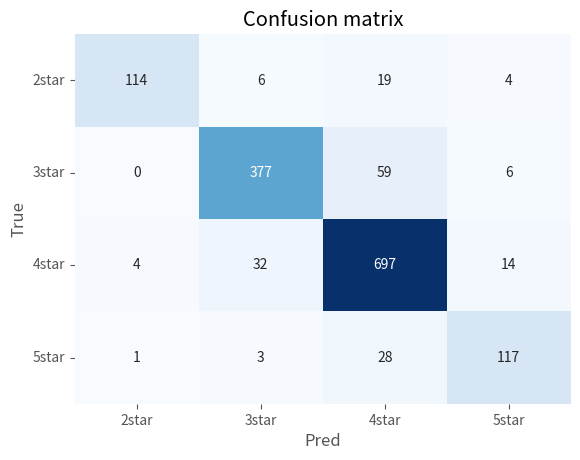

In [81]:
## Plot confusion matrix
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap=plt.cm.Blues, cbar=False)
ax.set(
    xlabel="Pred",
    ylabel="True",
    xticklabels=classes,
    yticklabels=classes,
    title="Confusion matrix",
)
plt.yticks(rotation=0)

3星與4星模型比較容易混淆，觀察資料集在3星4星的有些評論很像，但影響應該不大

### 2.5 TF-IDF

改使用 TF-IDF 的 DTM 來代表文章，訓練分類模型的效果。

In [82]:
vectorizer = TfidfVectorizer(max_features=1000)
vec_train = vectorizer.fit_transform(X_train)
vec_test = vectorizer.transform(X_test)
vocabulary = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(columns = vocabulary, data = vec_train.toarray())
tfidf_df

,一下,一位,一到,一夜,一大,一天,一家人,一張,一應俱全,一提,...,高雄,高雄市,鹽埕,鹽埕區,麥當勞,麵包,麻煩,點心,齊全,龍蝦
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.114549,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3450,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.305559,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3451,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.296953,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3452,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.146597,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3453,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [83]:
clf.fit(vec_train, y_train)
y_pred = clf.predict(vec_test)
y_pred_proba = clf.predict_proba(vec_test)

# results
## Accuracy, Precision, Recall, F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       2star       0.97      0.71      0.82       143
       3star       0.91      0.83      0.87       442
       4star       0.84      0.95      0.89       747
       5star       0.81      0.70      0.76       149

    accuracy                           0.86      1481
   macro avg       0.88      0.80      0.83      1481
weighted avg       0.87      0.86      0.86      1481



效果有差一點點，但沒有差很多。

### 2.6 CV

cross_validate：

- 返回多種指標的結果，包括 f1_macro、recall_macro 和 precision_macro，並能返回每折訓練和測試的時間、模型等詳細信息。

- 更適合用於綜合評估模型的性能並返回模型本身。

In [84]:
clf = LogisticRegression()
vec_train = TfidfVectorizer(max_features=1000).fit_transform(X_train)

scores = cross_validate(clf, vec_train, y_train, cv=5, scoring=("f1_macro", "recall_macro", "precision_macro"), return_estimator=True)
pprint(scores)

{'estimator': [LogisticRegression(),
               LogisticRegression(),
               LogisticRegression(),
               LogisticRegression(),
               LogisticRegression()],
 'fit_time': array([0.0484643 , 0.06170392, 0.05059052, 0.05424237, 0.04643321]),
 'score_time': array([0.01345611, 0.0126307 , 0.01082897, 0.0109992 , 0.        ]),
 'test_f1_macro': array([0.82790681, 0.84659815, 0.84085652, 0.86795407, 0.86187878]),
 'test_precision_macro': array([0.89261671, 0.8995354 , 0.91083013, 0.92506589, 0.93002889]),
 'test_recall_macro': array([0.78557983, 0.80866566, 0.79657492, 0.82752731, 0.81673075])}


cross_val_predict：

- 返回每一折的預測標籤，用來後續生成分類報告（classification_report）。

- 適用於需要比較預測結果的情況。

In [85]:
y_pred = cross_val_predict(clf, vec_train, y_train, cv=5)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

       2star       0.99      0.72      0.83       332
       3star       0.93      0.86      0.89      1031
       4star       0.84      0.96      0.90      1744
       5star       0.88      0.69      0.78       348

    accuracy                           0.88      3455
   macro avg       0.91      0.81      0.85      3455
weighted avg       0.89      0.88      0.88      3455



透過CV，performance有拉回來一點

## 3. 比較不同模型效果 (Decision Tree、Logistic Regression、SVM、Random Forest)

In [86]:
## pipeline: 資料處理 vectorizer + 分類器 clf
def train_cv(vectorizer, clf, X, y):
    # 1. 建立 Pipeline：把資料處理和分類器綁定
    # 這樣交叉驗證時，每次都會先正確地套用 vectorizer 再訓練模型，避免資料洩漏
    pipeline = make_pipeline(vectorizer, clf)
    
    # 2. 取得交叉驗證的預測結果 (注意：這裡直接傳入原始的 X，不需要提早轉換)
    # 它會自動幫你切 5 份，並妥善處理特徵轉換
    y_pred = cross_val_predict(pipeline, X, y, cv=5)
    
    # 3. 產出並回傳報告
    report = classification_report(y, y_pred, output_dict=True, zero_division=0)
    
    return report

雖然在單一次的測試集評估中，TF-IDF 的準確率 (0.86) 略低於 CountVectorizer (0.88)，但在前 Chapter2 2.5 節的交叉驗證 (CV) 中確認了其穩定性 (Accuracy 達 0.88)。
考量到 TF-IDF 能更有效降低常見無意義字詞的權重，突顯具鑑別度的特徵，因此後續模型比較我們統一選擇使用 TF-IDF 作為特徵提取方法。

In [87]:
vectorizer = TfidfVectorizer(max_features=1000)
clf = LogisticRegression()
result = train_cv(vectorizer, clf, X_train, y_train)

輸出：LogisticRegression、DecisionTree、SVC、RandomForest的各項檢測指標

In [88]:
# 準備訓練資料
X = data["words"]
y = data["hotel_class"]

# 把整個資料集七三切
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777, stratify=y
)
# 定義模型訓練組合
model_set = dict()
model_set['clf_logistic'] = LogisticRegression(max_iter=1000)
model_set['clf_dtree'] = DecisionTreeClassifier(random_state=777)
model_set['clf_svm'] = svm.SVC(probability=True) # 要使用SVM的predict_proba的話,必須在叫出SVC的時候就將probability設為True
model_set['clf_rf'] = RandomForestClassifier(random_state=777)

# 用 TF-IDF 作為特徵,跑每個模型的 CV
vectorizer = TfidfVectorizer(max_features=1000)
result_set = dict()
for name, clf in model_set.items():
    print(f"--- training {name} ---")
    result_set[name] = train_cv(vectorizer, clf, X_train, y_train)

--- training clf_logistic ---
--- training clf_dtree ---
--- training clf_svm ---
--- training clf_rf ---


分別觀察各個分類模型在不同類別的評估指標表現如何

In [89]:
for name, report in result_set.items():
    print(f"\n🟢 模型名稱：{name}")
    
    # 將字典轉換成 DataFrame 並轉置 (.T)，變成熟悉的表格格式
    df_report = pd.DataFrame(report).T
    
    # 小數點四捨五入到第 4 位，讓畫面更乾淨
    df_report = df_report.round(4)
    
    # 用 display 顯示漂亮的表格
    display(df_report)


🟢 模型名稱：clf_logistic


,precision,recall,f1-score,support
2star,0.9916,0.7139,0.8301,332.0000
3star,0.9248,0.8594,0.8909,1031.0000
4star,0.8401,0.9553,0.8940,1744.0000
5star,0.8727,0.6897,0.7705,348.0000
accuracy,0.8767,0.8767,0.8767,0.8767
macro avg,0.9073,0.8045,0.8464,3455.0000
weighted avg,0.8833,0.8767,0.8745,3455.0000



🟢 模型名稱：clf_dtree


,precision,recall,f1-score,support
2star,0.7484,0.6898,0.7179,332.0000
3star,0.8178,0.8186,0.8182,1031.0000
4star,0.8361,0.8481,0.8420,1744.0000
5star,0.6638,0.6638,0.6638,348.0000
accuracy,0.8055,0.8055,0.8055,0.8055
macro avg,0.7665,0.7551,0.7605,3455.0000
weighted avg,0.8048,0.8055,0.8050,3455.0000



🟢 模型名稱：clf_svm


,precision,recall,f1-score,support
2star,0.9915,0.6988,0.8198,332.0000
3star,0.9505,0.8390,0.8913,1031.0000
4star,0.8247,0.9685,0.8908,1744.0000
5star,0.8935,0.6753,0.7692,348.0000
accuracy,0.8744,0.8744,0.8744,0.8744
macro avg,0.9151,0.7954,0.8428,3455.0000
weighted avg,0.8852,0.8744,0.8719,3455.0000



🟢 模型名稱：clf_rf


,precision,recall,f1-score,support
2star,0.9787,0.6928,0.8113,332.000
3star,0.9025,0.8526,0.8768,1031.000
4star,0.8351,0.9524,0.8899,1744.000
5star,0.8911,0.6580,0.7570,348.000
accuracy,0.8680,0.8680,0.8680,0.868
macro avg,0.9018,0.7889,0.8338,3455.000
weighted avg,0.8746,0.8680,0.8651,3455.000


找出f1-score表現最好的模型是哪個，作為我們最終得到的分類器

In [90]:
max_score = 0
best_model_name = ""
best_model_metric = "f1-score"

print("📊 各模型的 Weighted F1-score：")
print("-" * 30)

## choose max f1-score model from result_set
for k, v in result_set.items():
    # 先把當前模型的分數抓出來
    current_score = v['weighted avg'][best_model_metric]
    
    # 印出當前模型的分數
    print(f"{k:20s}: {current_score:.4f}")
    
    # 判斷是否為目前最高分
    if current_score > max_score:
        max_score = current_score
        best_model_name = k

print("\n" + "=" * 30)
print(f"🏆 Best model: {best_model_name}")
print("=" * 30 + "\n")

# 印出最好模型的詳細報告
pprint(result_set[best_model_name])

📊 各模型的 Weighted F1-score：
------------------------------
clf_logistic        : 0.8745
clf_dtree           : 0.8050
clf_svm             : 0.8719
clf_rf              : 0.8651

🏆 Best model: clf_logistic

{'2star': {'f1-score': 0.830122591943958,
           'precision': 0.9916317991631799,
           'recall': 0.713855421686747,
           'support': 332.0},
 '3star': {'f1-score': 0.8908999497234792,
           'precision': 0.9248434237995825,
           'recall': 0.8593598448108632,
           'support': 1031.0},
 '4star': {'f1-score': 0.8940166353635632,
           'precision': 0.8401412002017146,
           'recall': 0.9552752293577982,
           'support': 1744.0},
 '5star': {'f1-score': 0.7704654895666132,
           'precision': 0.8727272727272727,
           'recall': 0.6896551724137931,
           'support': 348.0},
 'accuracy': 0.8767004341534008,
 'macro avg': {'f1-score': 0.8463761666494034,
               'precision': 0.9073359239729374,
               'recall': 0.80453641706

從結果可以看到Logistic Regression為我們的best model

把測試集套入至前面訓練的Logistic Regression

In [91]:
# 1. 確保 TF-IDF 轉換器已經被訓練過 (使用所有的 X_train)
vec_X_train = vectorizer.fit_transform(X_train)

# 2. 把我們選出的最佳模型拿出來，正式給它吃所有的訓練資料進行「訓練 (fit)」
best_clf = model_set['clf_logistic']
best_clf.fit(vec_X_train, y_train)

# 3. 把測試資料放進 TF-IDF 轉換器 (注意：這裡只用 transform，不包含 fit)
vec_X_test = vectorizer.transform(X_test)

# 4. 讓已經訓練好的最佳模型去「預測 (predict)」測試集
y_pred_test = best_clf.predict(vec_X_test)

# 5. 印出最終的期末考成績單
print("🎯 最佳模型 (Logistic Regression) 最終測試集表現：")
print("=" * 50)
print(classification_report(y_test, y_pred_test))

🎯 最佳模型 (Logistic Regression) 最終測試集表現：
              precision    recall  f1-score   support

       2star       0.97      0.71      0.82       143
       3star       0.91      0.83      0.87       442
       4star       0.84      0.95      0.89       747
       5star       0.81      0.70      0.76       149

    accuracy                           0.86      1481
   macro avg       0.88      0.80      0.83      1481
weighted avg       0.87      0.86      0.86      1481



最佳模型 (Logistic Regression) 圖表

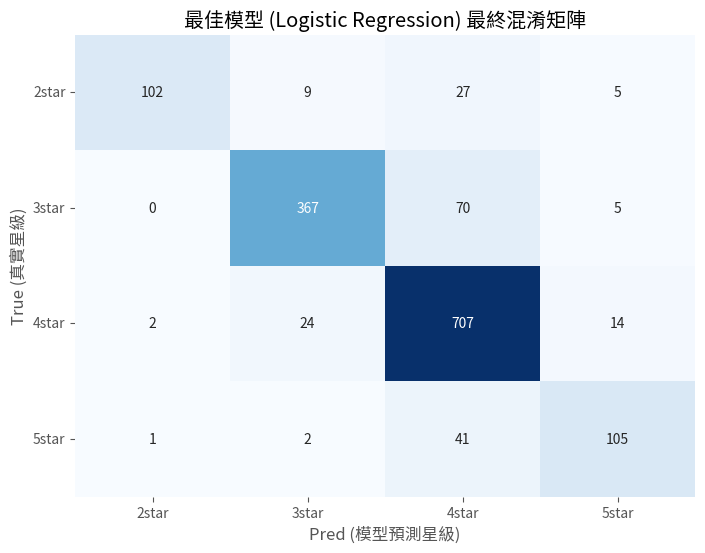

In [92]:
# 1. 取得剛剛最佳模型預測測試集的結果，計算混淆矩陣
cm = confusion_matrix(y_test, y_pred_test)

# 2. 取得星級類別標籤 (2star, 3star, 4star, 5star)
classes = best_clf.classes_

# 3. 開始畫圖 (稍微把圖片調大一點 figsize=(8, 6) 會更好看)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap=plt.cm.Blues, cbar=False)

ax.set(
    xlabel="Pred (模型預測星級)",
    ylabel="True (真實星級)",
    xticklabels=classes,
    yticklabels=classes,
    title="最佳模型 (Logistic Regression) 最終混淆矩陣"
)
plt.yticks(rotation=0)
plt.show()

輸入資料測試模型的效果

In [93]:
# 用一則範例評論測試看看
test_review = "房間 乾淨 服務 態度 親切 早餐 豐盛 推薦"
model_set['clf_logistic'].predict(vectorizer.transform([test_review]).toarray())

array(['3star'], dtype=object)

雖然輸入了高度正向的詞彙，模型卻預測為 3 星。這反映了資料集本身類別不平衡的限制，同時也暗示在 TripAdvisor 上，3 星飯店的評論也常出現大量的正面肯定用語（例如『乾淨、親切』），導致模型難以單憑這些基礎正向詞彙區分 3 星與 5 星的差異。

( 資料集分佈：4star 有 1744 筆、3star 有 1031 筆，但是 5star 只有少少的 348 筆。
因為模型平常看過太多3 星跟 4 星的評論了，所以當它遇到好話時，它會覺得「這應該是一間表現還不錯的 3 星或 4 星飯店」，而不敢輕易猜 5 星。)

## 4. 分析可解釋模型的結果

### 4.1 各字詞特徵的迴歸係數

因為LogisticRegression為我們的best model，所以我們用該模型結合cv tokenizer實作下面的範例

In [94]:
def plot_coef(logistic_reg_model, feature_names, top_n=10):
    # 選出某個類別的前10大影響力字詞
    log_odds = logistic_reg_model.coef_.T
    coef_df = pd.DataFrame(
        log_odds, 
        columns=logistic_reg_model.classes_, index=feature_names
    )
    for label in coef_df.columns:
        select_words = (
            coef_df[[label]]
            .sort_values(by=label, ascending=False)
            .iloc[np.r_[0:top_n, -top_n:0]]
        )
        word = select_words.index
        count = select_words[label]
        category_colors = np.where(
            select_words[label] >= 0, "darkseagreen", "rosybrown"
        )  # 設定顏色

        fig, ax = plt.subplots(figsize=(8, top_n*0.8))  # 設定畫布
        plt.rcParams["axes.unicode_minus"] = False

        ax.barh(word, count, color=category_colors)
        ax.invert_yaxis()
        ax.set_title(
            "Coeff increase/decrease odds ratio of 「" + label + "」 label the most",
            loc="left",
            size=16,
        )
        ax.set_ylabel("word", size=14)
        ax.set_xlabel("odds ratio", size=14)

從下面的圖表可以了解每個星級類別對應的關鍵字

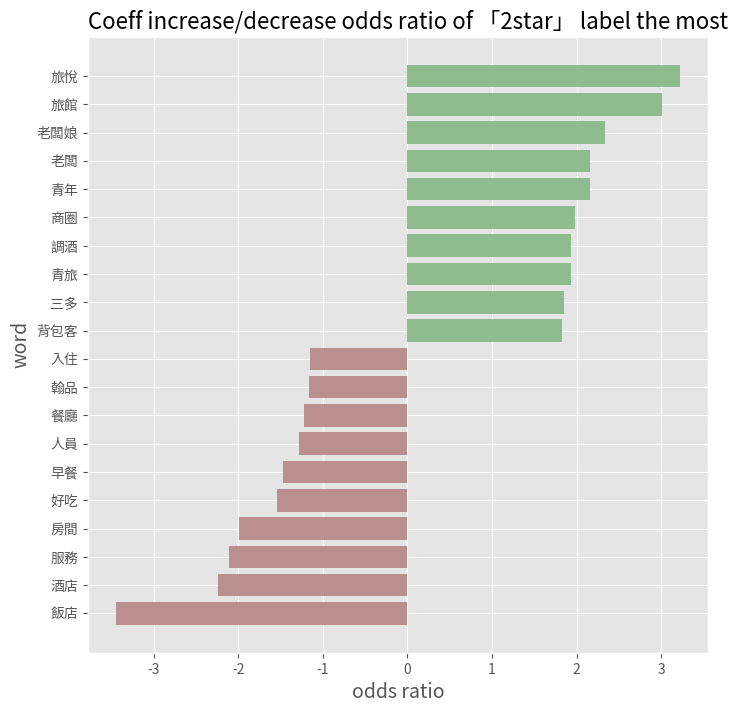

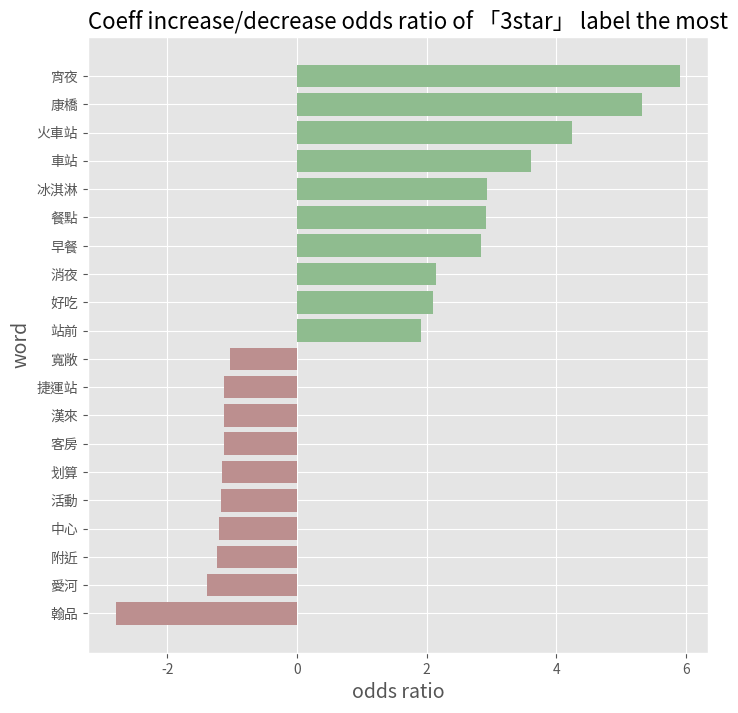

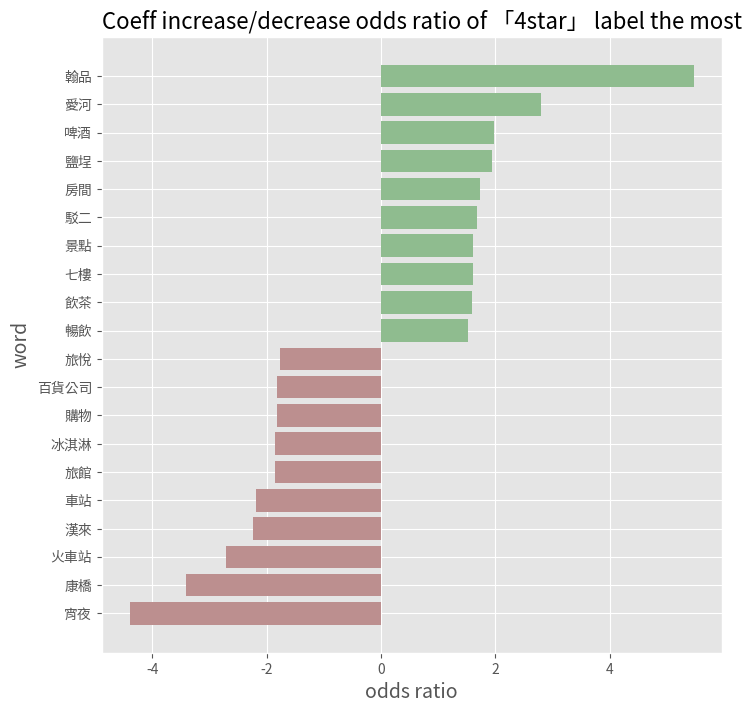

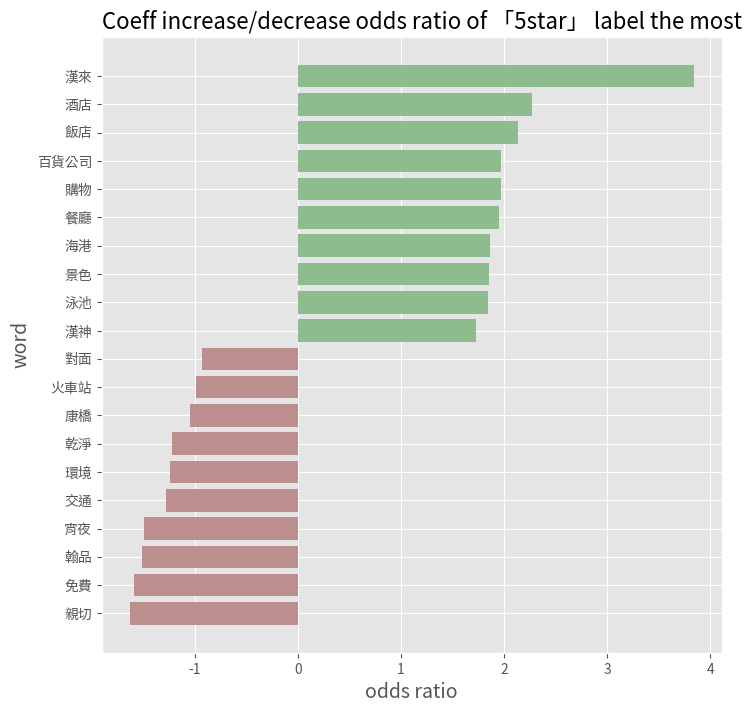

In [95]:
# 確保 vectorizer 跟 clf_logistic 使用同一份訓練資料配套
vectorizer = TfidfVectorizer(max_features=1000)
vec_train = vectorizer.fit_transform(X_train)
model_set['clf_logistic'] = LogisticRegression(max_iter=1000)
model_set['clf_logistic'].fit(vec_train, y_train)

plot_coef(
    logistic_reg_model=model_set['clf_logistic'],
    feature_names=vectorizer.get_feature_names_out(),
    top_n=10
)

發現這些詞跟星級的評論好像沒關聯，因此新增停用詞，將一些較無意義的詞停用

In [96]:
# 1. 重新精簡停用詞
core_stopwords = set(stopWords + [
    '任食', '仲有', '視圖', '感覺', '覺得', '入住', '真的', '真得', '一個', 
    '發現', '結果', '甚至', '整體', '地方', '內容', '下次', '部分','冰繳','急著','說值',
    '有著', '樣樣', '連住', '還算', '沒話', '看著', '看得到', '看得', '要來', '整間', '超有', '小點','太度',
    '看不到', '不負', '沒給', '可供', '有現', '有著', '要來', '不含', '停到', '檢入', '超極', '想換', '次帶'
])

def balanced_filter(text):
    words = pseg.cut(text.replace(" ", ""))
    # 允許：名詞(n)、形容詞(a)、動詞(v)
    # 排除：地名(ns)、人名(nr)、機構名(nt)、代名詞(r)
    allowed_pos = {'n', 'a', 'v'} 
    
    res = []
    for word, flag in words:
        if flag in allowed_pos and word not in core_stopwords and len(word) > 1:
            res.append(word)
    return " ".join(res)

# 套用新的過濾邏輯
X_train_final = X_train.apply(balanced_filter)

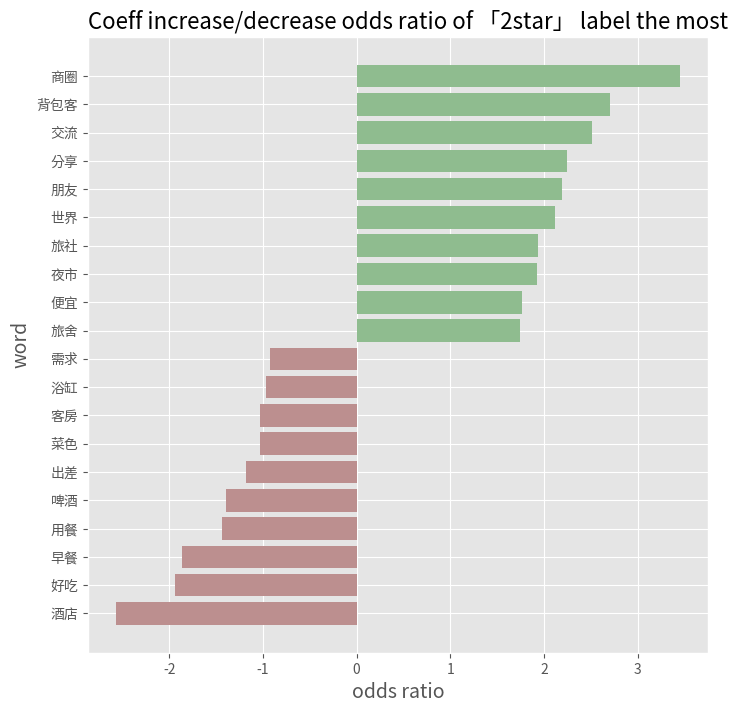

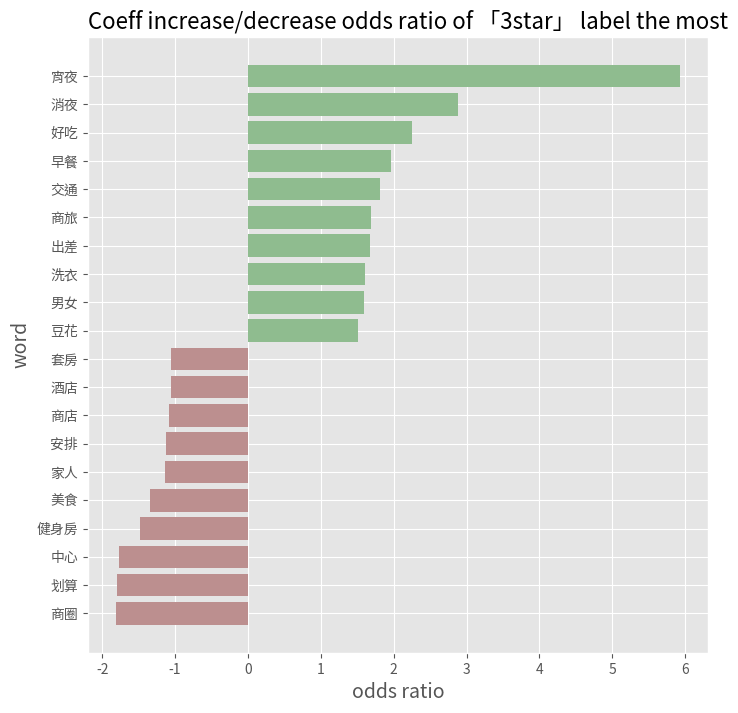

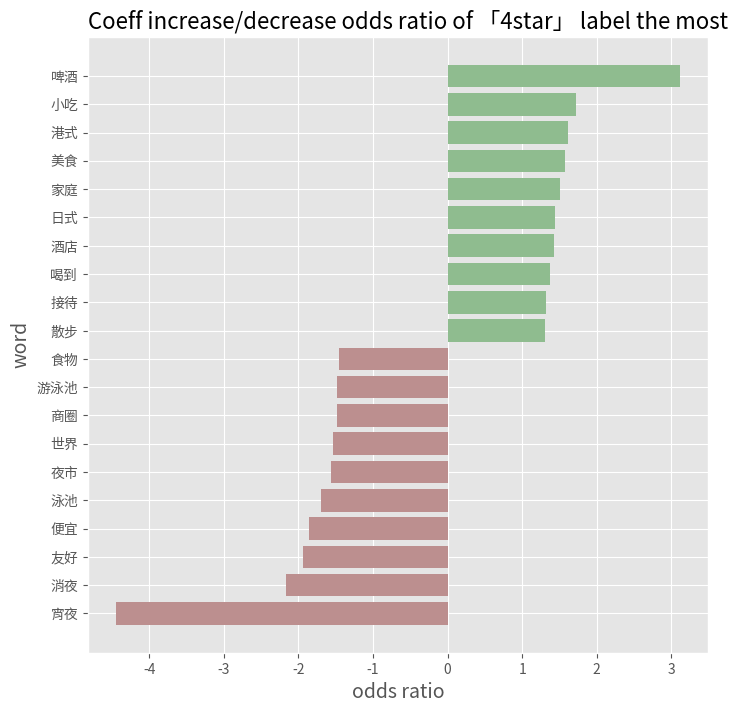

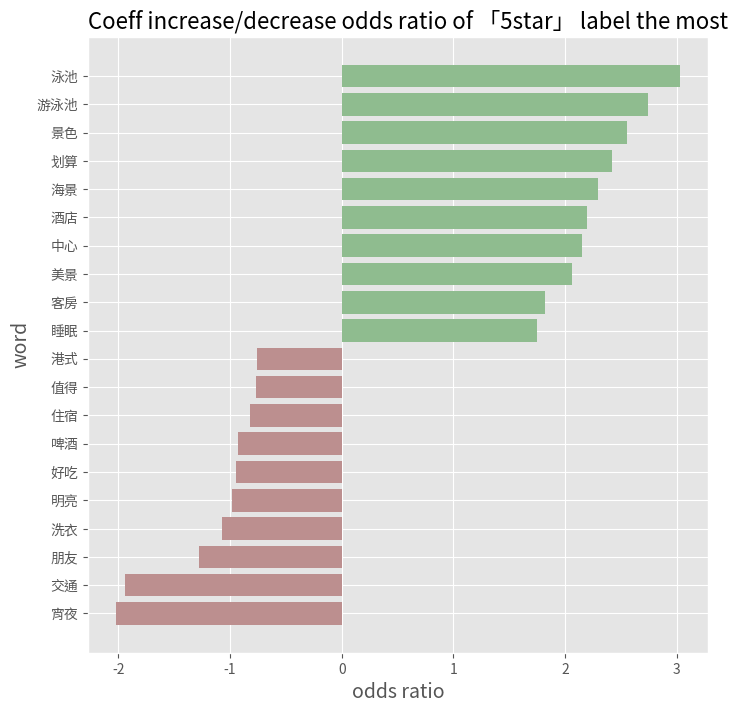

In [97]:
# 1. 初始化模型 (如果之前沒宣告過)
clf_logistic = LogisticRegression(max_iter=1000)

# # 2. 設定 Vectorizer 參數
# vectorizer = TfidfVectorizer(
#     max_features=500, 
#     max_df=0.4,    # 過濾掉太常見的詞 (如: 飯店、房間)
#     min_df=2       # 至少出現兩次的詞
# )

# 3. 轉換資料與訓練
# 請確保 X_train_final 是你經過前面詞性過濾後的資料
vec_train_final = vectorizer.fit_transform(X_train_final)
clf_logistic.fit(vec_train_final, y_train)

# 4. 繪圖
# 這裡確保傳入的是剛剛 fit 好的 clf_logistic
plot_coef(
    logistic_reg_model=clf_logistic,
    feature_names=vectorizer.get_feature_names_out(),
    top_n=10
)

 從 2 星到 5 星，住客的關注點從 「人情味與空間感」 (2★)-> 「餐飲細節」 (3★)->  「專業服務」 (4★) -> 「景觀與設施」 (5★) 遞進。負向係數的啟示： 會發現許多「基本優點」（如：不貴、乾淨、有現）在 5 星級模型中是負向係數。

## 5. 用訓練好的分類器檢視各星級的詳細分類表現

前面我們訓練好了分類器,這邊進一步觀察模型對各星級飯店的分類細節。
特別是看模型在哪些星級分類最準、哪些容易混淆,以及錯誤分類的樣本長什麼樣。

讀取testset

In [98]:
# 不需要另外讀資料,直接用前面切分好的 test set
ct = pd.DataFrame({
    'content': X_test.apply(lambda _: ''),   # 先佔位,下面再把原 content 補回
    'words': X_test.values,
    'hotel_class': y_test.values,
    'artUrl': ['test_' + str(i) for i in range(len(X_test))]
}, index=X_test.index)

# 把原始 content 補回來 (用 index 對應)
ct['content'] = data.loc[X_test.index, 'content'].values

ct.head()

,content,words,hotel_class,artUrl
3816,已數不清入住康橋多少次了之前出差若提早到達都能幸運的提前入房稍作休息此次可能因為前一晚房客較...,數不清 入住 康橋 多少次 出差 提早 到達 幸運 提前 入房 稍作 休息 前一晚 房客 時...,3star,test_0
2658,原本打算入住義大皇家酒店但是因為因緣際會下改成高雄翰品酒店覺得服務態度非常好房間也很時尚高級...,打算 入住 義大 皇家 酒店 因緣際會 改成 高雄 翰品 酒店 服務 態度 房間 時尚 高級...,4star,test_1
1056,房間寬敞明亮服務人員態度親切有禮早餐豐勝吃到飽現點現做熱騰騰的喔下次有機會來高雄還想來入住喔...,房間 寬敞 明亮 服務 人員 態度 親切 有禮 早餐 豐勝 吃到飽 現點現 熱騰騰 下次 機...,4star,test_2
4000,好好好謝謝親朋好友給我滿滿的祝福也祝福和我同一天生日的朋友生日快樂願妳你們心想事成平安快樂愛...,謝謝 親朋好友 給我 滿滿 祝福 祝福 同一 生日 朋友 生日快樂 心想事成 平安 快樂,3star,test_3
4093,這是我第一次去高雄和我在這裏住了晚工作人員都非常有禮貌友好和樂於助人和房間很乾淨和舒適酒店提...,高雄 工作 人員 禮貌 友好 樂於助人 房間 乾淨 舒適 酒店 提供 早餐 晚餐 客人 服務...,3star,test_4


In [99]:
# test set 已經清理過,這邊直接確認大小
print(f"test set 共 {len(ct)} 則評論")
ct.head()

test set 共 1481 則評論


,content,words,hotel_class,artUrl
3816,已數不清入住康橋多少次了之前出差若提早到達都能幸運的提前入房稍作休息此次可能因為前一晚房客較...,數不清 入住 康橋 多少次 出差 提早 到達 幸運 提前 入房 稍作 休息 前一晚 房客 時...,3star,test_0
2658,原本打算入住義大皇家酒店但是因為因緣際會下改成高雄翰品酒店覺得服務態度非常好房間也很時尚高級...,打算 入住 義大 皇家 酒店 因緣際會 改成 高雄 翰品 酒店 服務 態度 房間 時尚 高級...,4star,test_1
1056,房間寬敞明亮服務人員態度親切有禮早餐豐勝吃到飽現點現做熱騰騰的喔下次有機會來高雄還想來入住喔...,房間 寬敞 明亮 服務 人員 態度 親切 有禮 早餐 豐勝 吃到飽 現點現 熱騰騰 下次 機...,4star,test_2
4000,好好好謝謝親朋好友給我滿滿的祝福也祝福和我同一天生日的朋友生日快樂願妳你們心想事成平安快樂愛...,謝謝 親朋好友 給我 滿滿 祝福 祝福 同一 生日 朋友 生日快樂 心想事成 平安 快樂,3star,test_3
4093,這是我第一次去高雄和我在這裏住了晚工作人員都非常有禮貌友好和樂於助人和房間很乾淨和舒適酒店提...,高雄 工作 人員 禮貌 友好 樂於助人 房間 乾淨 舒適 酒店 提供 早餐 晚餐 客人 服務...,3star,test_4


觀察一下資料集的分佈狀況

In [100]:
ct['hotel_class'].value_counts()

hotel_class
4star    747
3star    442
5star    149
2star    143
Name: count, dtype: int64

直接用 best model 預測 test set 的 hotel_class

In [101]:
X = ct['words']
y = ct['hotel_class']

y_pred = model_set[best_model_name].predict(vectorizer.transform(X).toarray())
print(classification_report(y, y_pred, zero_division=0))

              precision    recall  f1-score   support

       2star       0.06      0.03      0.04       143
       3star       0.46      0.05      0.10       442
       4star       0.50      0.87      0.64       747
       5star       0.09      0.05      0.06       149

    accuracy                           0.46      1481
   macro avg       0.28      0.25      0.21      1481
weighted avg       0.41      0.46      0.36      1481



從 classification report 可以觀察:
- 哪個星級的飯店最容易被正確分類 (通常是極端的 5 星和 2 星)
- 哪些星級之間容易混淆 (例如 4 星和 5 星的評論語言風格可能很像)
- 各星級的 recall 和 precision 差異

In [102]:
ct['pred'] = y_pred
ct.loc[:, ['words', 'hotel_class', 'pred']]

,words,hotel_class,pred
3816,數不清 入住 康橋 多少次 出差 提早 到達 幸運 提前 入房 稍作 休息 前一晚 房客 時...,3star,2star
2658,打算 入住 義大 皇家 酒店 因緣際會 改成 高雄 翰品 酒店 服務 態度 房間 時尚 高級...,4star,4star
1056,房間 寬敞 明亮 服務 人員 態度 親切 有禮 早餐 豐勝 吃到飽 現點現 熱騰騰 下次 機...,4star,4star
4000,謝謝 親朋好友 給我 滿滿 祝福 祝福 同一 生日 朋友 生日快樂 心想事成 平安 快樂,3star,5star
4093,高雄 工作 人員 禮貌 友好 樂於助人 房間 乾淨 舒適 酒店 提供 早餐 晚餐 客人 服務...,3star,4star
...,...,...,...
4625,舒適 有家 感覺 他間 青年 旅館 感受 不到 附近 商家 百貨公司 附近 交通 發達 下次 再來,2star,4star
415,高雄 印象 深刻 美景 舒適 酒店 房間 一流 餐廳 設施 員工 專業 熱情 大部分 酒店 ...,5star,4star
3944,地點 超好 火車站 捷運 火車 方便 四周 生活 機能 熱鬧 晚上 餐廳 選擇 房間 簡潔 ...,3star,4star
4106,次來 康橋 宵夜 特別 好吃 豆花 還有旦 推薦 服務 態度 親切 昨天 六合 夜市,3star,4star


將錯誤分類的結果篩選出來

In [103]:
false_pred = ct.query("hotel_class != pred").loc[:, ['words', 'hotel_class', 'pred']]
false_pred

,words,hotel_class,pred
3816,數不清 入住 康橋 多少次 出差 提早 到達 幸運 提前 入房 稍作 休息 前一晚 房客 時...,3star,2star
4000,謝謝 親朋好友 給我 滿滿 祝福 祝福 同一 生日 朋友 生日快樂 心想事成 平安 快樂,3star,5star
4093,高雄 工作 人員 禮貌 友好 樂於助人 房間 乾淨 舒適 酒店 提供 早餐 晚餐 客人 服務...,3star,4star
110,留在 出差 高雄 寶石 酒店 漂亮 裝修 現在 改進 說明 坐落 城市 中心 俯瞰 港口 樓...,5star,4star
3445,久久 一次 高雄 出差 火車站 看到 飯店 服務 人員 親切 主動 幫忙 升級 房型 貼心 ...,3star,4star
...,...,...,...
356,高雄 快會 發現 高雄 好玩 旅遊 地方 遠離 難看 工業 城區 需要 住宿 地方 一流 購...,5star,4star
4625,舒適 有家 感覺 他間 青年 旅館 感受 不到 附近 商家 百貨公司 附近 交通 發達 下次 再來,2star,4star
415,高雄 印象 深刻 美景 舒適 酒店 房間 一流 餐廳 設施 員工 專業 熱情 大部分 酒店 ...,5star,4star
3944,地點 超好 火車站 捷運 火車 方便 四周 生活 機能 熱鬧 晚上 餐廳 選擇 房間 簡潔 ...,3star,4star


觀察看看 2 星飯店的評論 (最低星級),模型是否會誤判成其他星級

In [104]:
false_pred.loc[false_pred['hotel_class'] == '2star', :]

,words,hotel_class,pred
4773,旅馆 老板 超级 漂亮 超级 热情 整个 旅馆 感觉 温馨 交谊厅 茶水 布置 简直 超乎 ...,2star,4star
4803,想要 再次 嚐試 青春 氣息 尋覓 年輕人 聚集 青年 旅館 適合 落腳 休憩 捷運站 交通...,2star,4star
4532,店員 服務 態度 超好 星期二 舉辦 國家 交流 活動 十分 不錯 附近 商場 方便 房間 ...,2star,4star
4643,誤打誤撞 二人 房有 獨立 衛浴 房間 空間 十分 清潔 青旅 價錢 酒店 房間 職員 友善...,2star,3star
4489,很棒 優質 旅館 服務 優質 感覺 親切 服務 不錯 感覺 特別 心動 感謝 朋友 介紹 價...,2star,4star
...,...,...,...
4787,進到 三樓 溫馨 空間 桌椅 擺設 交誼廳 提供 桌遊 一群 感到 興奮 躍躍欲試 櫃檯 人...,2star,4star
4912,絕佳 地理 位置 極好 服務 高性價比 高雄 後悔 選擇 下次 高雄 還會來 將這個 青旅 ...,2star,3star
4587,地點 一流 三多 商圈 新光三越 旁邊 對面 興中 夜市 實在 沒什麼 當天 點多 來到 職...,2star,4star
4817,旅客 背包客 誠摯 推薦 高雄 旅悅 青年 旅社 住戶 員工 親切 美麗 大方 走進 旅社 ...,2star,4star


挑選一則被誤判的 2 星評論觀察看看,分析為何會被預測成其他星級

In [105]:
# 抓第一筆 2star 被誤判的評論 words
low_mis = false_pred.loc[false_pred['hotel_class'] == '2star']
if len(low_mis) > 0:
    idx = low_mis.index[0]
    pprint(low_mis.loc[idx, 'words'])
else:
    print("沒有 2star 的誤判樣本")

('旅馆 老板 超级 漂亮 超级 热情 整个 旅馆 感觉 温馨 交谊厅 茶水 布置 简直 超乎 想象 卫生间 各种 香水 真是 太棒 分享 不错 地方 超级 '
 '贴心 一来 高雄 已经 喜欢 这里 地理 位置 哪里 方便')


In [106]:
# 看原始評論內容
if len(low_mis) > 0:
    idx = low_mis.index[0]
    print(ct.loc[idx, 'content'])

非常棒的旅馆老板娘超级漂亮超级热情整个旅馆让人感觉很温馨交谊厅茶水间布置的简直超乎你想象还有卫生间还有各种香水真是太棒了还跟我分享了好多很不错的地方超级贴心的让我一来高雄就已经喜欢上这里啦地理位置非常好去哪里都很方便


之前的 Odds Ratio 圖表可以發現，「老闆娘」、「青旅」、「小窩」、「交宜（廳）」 是 2 星級的強特徵。

誤判情境： 如果一家 5 星級飯店的評論寫道：「飯店很有家的感覺，經理像老闆娘一樣親切，還在交誼廳跟我們聊天，讓我們覺得像待在自己的小窩一樣。」

模型邏輯： 雖然這是好評，但因為這些詞彙在 2 星級數據中出現頻率極高，模型會認為「這聽起來像是一間很棒的青年旅館」，進而將其歸類為 2 星。

## 6. 主題模型
主題模型（Topic Modeling）是一種無監督學習技術，用於從大量文本中自動識別潛在的主題。本次使用LDA模型進行主題分析，並結合視覺化工具與情緒分析，探索文本資料中的主題分佈與情緒趨勢。

In [107]:
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

### 6.1 資料前處理

In [108]:
# 重新讀四家飯店做 LDA (無監督學習,用全部資料效果更好)
df5 = pd.read_excel("./raw_data2/5star.xlsx"); df5["hotel_class"] = "5star"
df4 = pd.read_excel("./raw_data2/4star.xlsx"); df4["hotel_class"] = "4star"
df3 = pd.read_excel("./raw_data2/3star.xlsx"); df3["hotel_class"] = "3star"
df2 = pd.read_excel("./raw_data2/2star.xlsx"); df2["hotel_class"] = "2star"
sma_data = pd.concat([df5, df4, df3, df2], ignore_index=True)
sma_data["artUrl"] = "all_" + sma_data.index.astype(str)
sma_data.head(3)

,reviewer,location,contributions,user_helpful_votes,date_posted,rating,title,content,stay_date,trip_type,hotel_class,artUrl
0,JennyYu 已於 2024年11月 發表一則評論,月 發表一則評論\n台灣台北,225.0,6.0,2024年11月,5,✨【愛上高雄漢來飯店的原因】✨,✨【愛上高雄漢來飯店的原因】✨\n這次帶著喜歡庫洛米的Yoyo，入住高雄漢來飯店的三麗鷗主題...,NaN,NaN,5star,all_0
1,ANDYCKH 已於 2024年8月 發表一則評論,月 發表一則評論\n香港,91.0,1.0,2024年8月,5,超可愛Kuromi主題房,"復活節假期帶老婆到高雄看5月天演唱會, 住了3晚漢來大飯店, 原因100%是因為有Kurom...",NaN,NaN,5star,all_1
2,IG denden.travel 已於 2023年12月 發表一則評論,月 發表一則評論\n台灣台北,2465.0,27.0,2023年12月,5,大概是全世界最用心的三麗鷗主題房,大概是全世界最用心的三麗鷗主題房～\n大家好，我是膚淺喜歡被讚美的丹丹，這篇要介紹的是高雄漢...,NaN,NaN,5star,all_2


In [109]:
sma_data = sma_data.dropna(subset=['content', 'hotel_class'])
# 移除網址、只留下中文字
sma_data["content"] = sma_data["content"].astype(str).str.replace("(http|https)://\\S+", "", regex=True)
sma_data["content"] = sma_data["content"].str.replace("[^\u4e00-\u9fa5]+", "", regex=True)
sma_data = sma_data[sma_data["content"].str.len() > 0].reset_index(drop=True)
sma_data.head(3)

,reviewer,location,contributions,user_helpful_votes,date_posted,rating,title,content,stay_date,trip_type,hotel_class,artUrl
0,JennyYu 已於 2024年11月 發表一則評論,月 發表一則評論\n台灣台北,225.0,6.0,2024年11月,5,✨【愛上高雄漢來飯店的原因】✨,愛上高雄漢來飯店的原因這次帶著喜歡庫洛米的入住高雄漢來飯店的三麗鷗主題房我們選擇的是美樂蒂和...,NaN,NaN,5star,all_0
1,ANDYCKH 已於 2024年8月 發表一則評論,月 發表一則評論\n香港,91.0,1.0,2024年8月,5,超可愛Kuromi主題房,復活節假期帶老婆到高雄看月天演唱會住了晚漢來大飯店原因是因為有主題房老婆是超級酒店離地鐵站並...,NaN,NaN,5star,all_1
2,IG denden.travel 已於 2023年12月 發表一則評論,月 發表一則評論\n台灣台北,2465.0,27.0,2023年12月,5,大概是全世界最用心的三麗鷗主題房,大概是全世界最用心的三麗鷗主題房大家好我是膚淺喜歡被讚美的丹丹這篇要介紹的是高雄漢來大飯店三...,NaN,NaN,5star,all_2


In [110]:
# 設定繁體中文詞庫
jieba.set_dictionary("./dict/dict.txt")

# 新增stopwords
with open("./dict/stopwords.txt", encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

In [111]:
# 設定斷詞 function
def getToken(row):
    seg_list = jieba.cut(row, cut_all=False)
    seg_list = [w for w in seg_list if w not in stopWords and len(w) > 1]
    return seg_list
sma_data = sma_data[sma_data["content"].notna()]  # 移除 content 欄為 NaN 的列
sma_data["words"] = sma_data["content"].apply(getToken)

Building prefix dict from c:\Users\acer\Desktop\中山\114下\社群媒體分析\讀書會情緒分析\SMA_G2_PRJ1\dict\dict.txt ...
2026-04-28 18:12:25,939 : DEBUG : Building prefix dict from c:\Users\acer\Desktop\中山\114下\社群媒體分析\讀書會情緒分析\SMA_G2_PRJ1\dict\dict.txt ...
Loading model from cache C:\Users\acer\AppData\Local\Temp\jieba.ud4559cd62f33f985c3a5821e86eea8ec.cache
2026-04-28 18:12:25,941 : DEBUG : Loading model from cache C:\Users\acer\AppData\Local\Temp\jieba.ud4559cd62f33f985c3a5821e86eea8ec.cache
Loading model cost 0.623 seconds.
2026-04-28 18:12:26,563 : DEBUG : Loading model cost 0.623 seconds.
Prefix dict has been built successfully.
2026-04-28 18:12:26,563 : DEBUG : Prefix dict has been built successfully.


In [112]:
# 加入自定義的停用詞（可隨時擴充）
extra_stopwords = {
    '提供', '選擇', '下次', '入住', '感覺', '分鐘',"感覺", "覺得", "真的", "飯店", "酒店", 
    "這次", "很多", "可以", "我們", "他們", "自己", "還是", "因為", "所以", "但是", "如果", 
    "就是", "比較"
}

# 合併並轉為 set（效率更高）
stopWords = set(stopWords).union(extra_stopwords)

In [113]:
sma_data = sma_data[sma_data["content"].notna()]  # 移除 content 欄為 NaN 的列
sma_data["words"] = sma_data["content"].apply(getToken)

# 只保留必要欄位
sma_data = sma_data[["content", "artUrl", "hotel_class", "date_posted" , "words"]]
sma_data.head(3)

,content,artUrl,hotel_class,date_posted,words
0,愛上高雄漢來飯店的原因這次帶著喜歡庫洛米的入住高雄漢來飯店的三麗鷗主題房我們選擇的是美樂蒂和...,all_0,5star,2024年11月,"[愛上, 高雄, 漢來, 原因, 喜歡, 庫洛米, 高雄, 漢來, 三麗鷗, 主題房, 美樂..."
1,復活節假期帶老婆到高雄看月天演唱會住了晚漢來大飯店原因是因為有主題房老婆是超級酒店離地鐵站並...,all_1,5star,2024年8月,"[復活節, 假期, 老婆, 高雄, 看月天, 演唱會, 晚漢來, 原因, 主題房, 老婆, ..."
2,大概是全世界最用心的三麗鷗主題房大家好我是膚淺喜歡被讚美的丹丹這篇要介紹的是高雄漢來大飯店三...,all_2,5star,2023年12月,"[全世界, 用心, 三麗鷗, 主題房, 膚淺, 喜歡, 讚美, 丹丹, 這篇要, 介紹, 高..."


### 6.2 Lexicon-based主題模型

分成6種主題，我們先預設每個主題可能會有哪些關鍵字 (用我們自己的字典)

In [114]:
topic_lexicon = {
    "房間設施": [
        "房間", "客房", "房型", "床", "床墊", "枕頭", "浴室", "浴缸", "淋浴",
        "廁所", "冷氣", "空調", "電視", "冰箱", "設備", "設施", "空間",
        "隔音", "窗戶", "電梯", "熱水"
    ],

    "服務與接待": [
        "服務", "人員", "員工", "櫃檯", "櫃台", "接待", "態度", "親切",
        "熱心", "專業", "協助", "幫忙", "入住", "退房", "房務", "服務員"
    ],

    "餐飲體驗": [
        "早餐", "餐廳", "餐點", "食物", "菜色", "咖啡", "飲料", "晚餐",
        "自助", "buffet", "好吃", "美味", "料理", "點心", "水果"
    ],

    "地點交通": [
        "地點", "位置", "交通", "方便", "便利", "附近", "捷運", "車站",
        "火車站", "高鐵", "機場", "公車", "步行", "走路", "距離",
        "商圈", "夜市", "停車"
    ],

    "價格與CP值": [
        "價格", "價錢", "房價", "便宜", "貴", "划算", "值得", "超值",
        "合理", "優惠", "CP值", "性價比", "物超所值", "推薦"
    ],

    "環境與清潔": [
        "乾淨", "整潔", "清潔", "衛生", "舒適", "舒服", "安靜", "吵",
        "噪音", "老舊", "陳舊", "潮濕", "霉味", "環境", "明亮",
        "寬敞", "漂亮", "高級", "豪華"
    ]
}

將斷詞後的doc['words']轉換成list

In [115]:
docs = sma_data['words'].to_list()
docs[0]

['愛上',
 '高雄',
 '漢來',
 '原因',
 '喜歡',
 '庫洛米',
 '高雄',
 '漢來',
 '三麗鷗',
 '主題房',
 '美樂蒂',
 '庫洛米',
 '戀愛',
 '糖果屋',
 '家庭',
 '套房',
 '房間',
 '布置',
 '夢幻',
 '隨手',
 '一拍',
 '美照',
 '雙人床',
 '稍微',
 '一點',
 '完全',
 '影響',
 '超棒',
 '體驗',
 '退房',
 '貼心',
 '服務',
 '接待',
 '姐姐',
 '親切',
 '溫柔',
 '踏進',
 '感受到',
 '賓至如歸',
 '溫暖',
 '退房',
 '遇到',
 '洪仕達',
 '先生',
 '同樣',
 '感受到',
 '漢來',
 '水準',
 '服務',
 '感到',
 '用心',
 '難忘',
 '莫過於',
 '接駁車',
 '司機',
 '何聰坤',
 '先生',
 '悉心',
 '照顧',
 '一路',
 '充滿',
 '感謝',
 '漢來',
 '到達',
 '高鐵',
 '貼心',
 '準備',
 '詢問',
 '需要',
 '心頭',
 '一暖',
 '細心',
 '真誠',
 '對漢來',
 '深刻',
 '美好',
 '印象',
 '漢來',
 '每位',
 '員工',
 '展現出',
 '專業',
 '真誠',
 '態度',
 '高雄',
 '之旅',
 '圓滿',
 '尋找',
 '充滿',
 '溫度',
 '住宿',
 '體驗',
 '高雄',
 '漢來',
 '不二',
 '之選',
 '小小',
 '建議',
 '回程',
 '接駁車',
 '最後',
 '一班在點',
 '太早',
 '希望',
 '未來',
 '延長',
 '期待',
 '住到',
 '面海',
 '房型',
 '感受',
 '高雄',
 '美麗',
 '景致',
 '高雄',
 '漢來',
 '三麗鷗',
 '主題房',
 '家庭',
 '旅行',
 '貼心',
 '服務',
 '台灣']

In [116]:
def classify_lexicon(tokens, topic_lexicon):
    scores = {}

    for topic, keywords in topic_lexicon.items():
        score = sum(1 for word in tokens if word in keywords)
        scores[topic] = score

    max_score = max(scores.values())

    if max_score == 0:
        main_topic = "其他"
    else:
        main_topic = max(scores, key=scores.get)

    return main_topic, scores

對每則評論做主題分類，看每個主題字出現的多寡來決定最後的lexicon_topic

In [117]:
lexicon_result = sma_data["words"].apply(
    lambda x: classify_lexicon(x, topic_lexicon)
)

sma_data["lexicon_topic"] = lexicon_result.apply(lambda x: x[0])
sma_data["topic_scores"] = lexicon_result.apply(lambda x: x[1])

sma_data[["content", "hotel_class", "lexicon_topic", "topic_scores"]].head()

,content,hotel_class,lexicon_topic,topic_scores
0,愛上高雄漢來飯店的原因這次帶著喜歡庫洛米的入住高雄漢來飯店的三麗鷗主題房我們選擇的是美樂蒂和...,5star,服務與接待,"{'房間設施': 2, '服務與接待': 10, '餐飲體驗': 0, '地點交通': 1,..."
1,復活節假期帶老婆到高雄看月天演唱會住了晚漢來大飯店原因是因為有主題房老婆是超級酒店離地鐵站並...,5star,房間設施,"{'房間設施': 3, '服務與接待': 0, '餐飲體驗': 0, '地點交通': 1, ..."
2,大概是全世界最用心的三麗鷗主題房大家好我是膚淺喜歡被讚美的丹丹這篇要介紹的是高雄漢來大飯店三...,5star,房間設施,"{'房間設施': 13, '服務與接待': 8, '餐飲體驗': 5, '地點交通': 2,..."
3,若活動範圍在南高雄算是可以選擇的酒店之一離捷運遠需利用計程車過去每年農曆春節常常會住這邊一晚...,5star,地點交通,"{'房間設施': 1, '服務與接待': 1, '餐飲體驗': 2, '地點交通': 5, ..."
4,我覺得大廳環境不錯但走進去沒人理我好幾分鐘不知道哪裡入住最後是我自己問才知道是找有點久湯裡面...,5star,環境與清潔,"{'房間設施': 1, '服務與接待': 0, '餐飲體驗': 2, '地點交通': 0, ..."


把每個主題分數拆成欄位


In [118]:
topic_score_df = sma_data["topic_scores"].apply(pd.Series)

sma_data_lexicon = pd.concat([sma_data, topic_score_df], axis=1)

sma_data_lexicon.head(3)

,content,artUrl,hotel_class,date_posted,words,lexicon_topic,topic_scores,房間設施,服務與接待,餐飲體驗,地點交通,價格與CP值,環境與清潔
0,愛上高雄漢來飯店的原因這次帶著喜歡庫洛米的入住高雄漢來飯店的三麗鷗主題房我們選擇的是美樂蒂和...,all_0,5star,2024年11月,"[愛上, 高雄, 漢來, 原因, 喜歡, 庫洛米, 高雄, 漢來, 三麗鷗, 主題房, 美樂...",服務與接待,"{'房間設施': 2, '服務與接待': 10, '餐飲體驗': 0, '地點交通': 1,...",2,10,0,1,0,0
1,復活節假期帶老婆到高雄看月天演唱會住了晚漢來大飯店原因是因為有主題房老婆是超級酒店離地鐵站並...,all_1,5star,2024年8月,"[復活節, 假期, 老婆, 高雄, 看月天, 演唱會, 晚漢來, 原因, 主題房, 老婆, ...",房間設施,"{'房間設施': 3, '服務與接待': 0, '餐飲體驗': 0, '地點交通': 1, ...",3,0,0,1,0,0
2,大概是全世界最用心的三麗鷗主題房大家好我是膚淺喜歡被讚美的丹丹這篇要介紹的是高雄漢來大飯店三...,all_2,5star,2023年12月,"[全世界, 用心, 三麗鷗, 主題房, 膚淺, 喜歡, 讚美, 丹丹, 這篇要, 介紹, 高...",房間設施,"{'房間設施': 13, '服務與接待': 8, '餐飲體驗': 5, '地點交通': 2,...",13,8,5,2,1,2


看每個主題的評論數量


In [119]:
topic_count = sma_data_lexicon["lexicon_topic"].value_counts()

topic_count

lexicon_topic
服務與接待     2157
房間設施       814
地點交通       814
餐飲體驗       537
環境與清潔      396
價格與CP值     145
其他          73
Name: count, dtype: int64

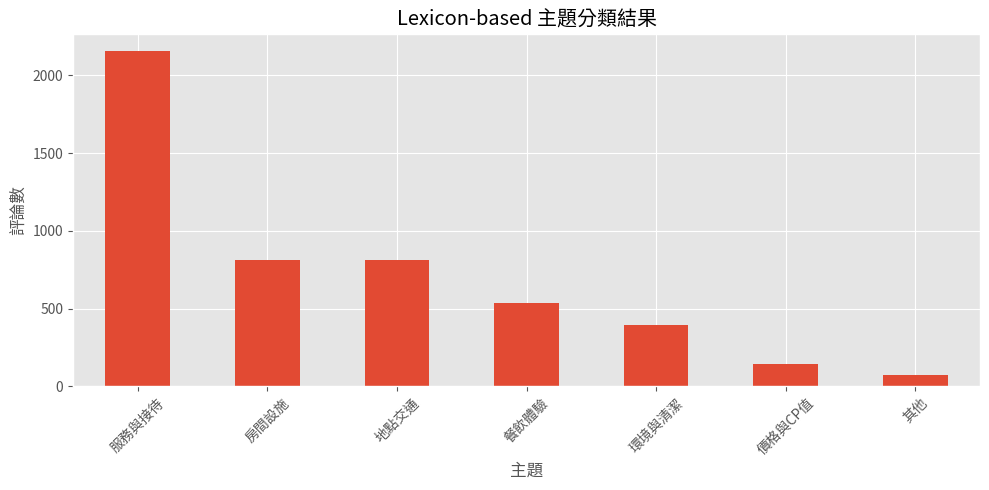

In [120]:
plt.figure(figsize=(10, 5))

topic_count.plot(kind="bar")

plt.title("Lexicon-based 主題分類結果")
plt.xlabel("主題")
plt.ylabel("評論數")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

將星級與主題做結合，比如說在2星，"地點交通"和"服務與接待"是較常出現的

In [121]:
hotel_topic_count = pd.crosstab(
    sma_data_lexicon["hotel_class"],
    sma_data_lexicon["lexicon_topic"],
    normalize="index"
)

hotel_topic_count

lexicon_topic,價格與CP值,其他,地點交通,房間設施,服務與接待,環境與清潔,餐飲體驗
hotel_class,,,,,,,
2star,0.061053,0.044211,0.265263,0.166316,0.240000,0.185263,0.037895
3star,0.014936,0.006110,0.190088,0.099796,0.446029,0.054311,0.188730
4star,0.033320,0.016058,0.145725,0.168206,0.502208,0.067041,0.067443
5star,0.022133,0.006036,0.090543,0.340040,0.271630,0.122736,0.146881


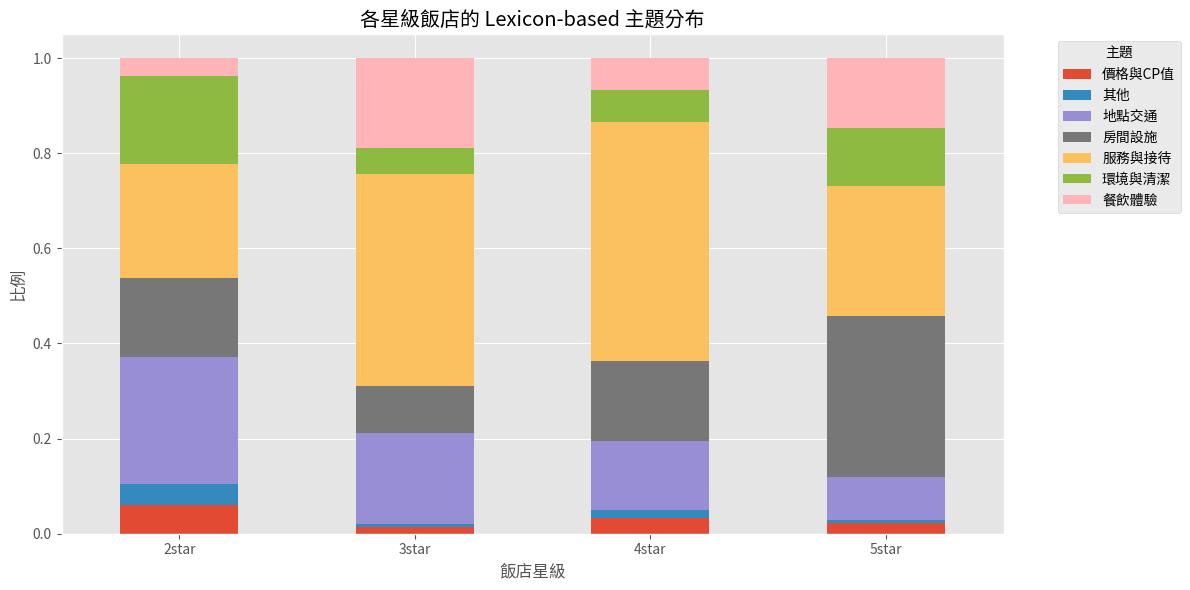

In [122]:
hotel_topic_count.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("各星級飯店的 Lexicon-based 主題分布")
plt.xlabel("飯店星級")
plt.ylabel("比例")
plt.xticks(rotation=0)
plt.legend(title="主題", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 6.3 LDA主題模型

#### 6.3.1 正式處理主題分析

將斷詞後的doc['words']轉換成list

In [123]:
docs = sma_data['words'].to_list()
docs[0]

['愛上',
 '高雄',
 '漢來',
 '原因',
 '喜歡',
 '庫洛米',
 '高雄',
 '漢來',
 '三麗鷗',
 '主題房',
 '美樂蒂',
 '庫洛米',
 '戀愛',
 '糖果屋',
 '家庭',
 '套房',
 '房間',
 '布置',
 '夢幻',
 '隨手',
 '一拍',
 '美照',
 '雙人床',
 '稍微',
 '一點',
 '完全',
 '影響',
 '超棒',
 '體驗',
 '退房',
 '貼心',
 '服務',
 '接待',
 '姐姐',
 '親切',
 '溫柔',
 '踏進',
 '感受到',
 '賓至如歸',
 '溫暖',
 '退房',
 '遇到',
 '洪仕達',
 '先生',
 '同樣',
 '感受到',
 '漢來',
 '水準',
 '服務',
 '感到',
 '用心',
 '難忘',
 '莫過於',
 '接駁車',
 '司機',
 '何聰坤',
 '先生',
 '悉心',
 '照顧',
 '一路',
 '充滿',
 '感謝',
 '漢來',
 '到達',
 '高鐵',
 '貼心',
 '準備',
 '詢問',
 '需要',
 '心頭',
 '一暖',
 '細心',
 '真誠',
 '對漢來',
 '深刻',
 '美好',
 '印象',
 '漢來',
 '每位',
 '員工',
 '展現出',
 '專業',
 '真誠',
 '態度',
 '高雄',
 '之旅',
 '圓滿',
 '尋找',
 '充滿',
 '溫度',
 '住宿',
 '體驗',
 '高雄',
 '漢來',
 '不二',
 '之選',
 '小小',
 '建議',
 '回程',
 '接駁車',
 '最後',
 '一班在點',
 '太早',
 '希望',
 '未來',
 '延長',
 '期待',
 '住到',
 '面海',
 '房型',
 '感受',
 '高雄',
 '美麗',
 '景致',
 '高雄',
 '漢來',
 '三麗鷗',
 '主題房',
 '家庭',
 '旅行',
 '貼心',
 '服務',
 '台灣']

建立並過濾詞彙表（dictionary），只保留特定條件的詞彙

    no_below=5 出現在少於 5 篇文章中的詞會被移除
    
    no_above=0.99 出現在超過 99% 文件中的詞會被移除

In [124]:
dictionary = Dictionary(docs)

dictionary.filter_extremes(no_below=5, no_above=0.99)
print(dictionary)

2026-04-28 18:13:24,496 : INFO : adding document #0 to Dictionary<0 unique tokens: []>
2026-04-28 18:13:24,689 : INFO : built Dictionary<14518 unique tokens: ['一拍', '一暖', '一班在點', '一路', '一點']...> from 4936 documents (total 135964 corpus positions)
2026-04-28 18:13:24,704 : INFO : Dictionary lifecycle event {'msg': "built Dictionary<14518 unique tokens: ['一拍', '一暖', '一班在點', '一路', '一點']...> from 4936 documents (total 135964 corpus positions)", 'datetime': '2026-04-28T18:13:24.704310', 'gensim': '4.3.3', 'python': '3.11.0 | packaged by Anaconda, Inc. | (main, Mar  1 2023, 18:18:21) [MSC v.1916 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'created'}
2026-04-28 18:13:24,709 : INFO : discarding 11705 tokens: [('一拍', 1), ('一暖', 1), ('一班在點', 1), ('三麗鷗', 2), ('主題房', 3), ('何聰坤', 1), ('圓滿', 4), ('夢幻', 2), ('太早', 2), ('對漢來', 3)]...
2026-04-28 18:13:24,709 : INFO : keeping 2813 tokens which were in no less than 5 and no more than 4886 (=99.0%) documents
2026-04-28 18:13:24,723

Dictionary<2813 unique tokens: ['一路', '一點', '不二', '之旅', '之選']...>


將斷詞結果建構語料庫(corpus)之後，利用語料庫把每篇文章數字化。
<br>每個詞彙都被賦予一個 ID 及頻率(word_id，word_frequency)。<br>

舉例來說：<br>
第一篇文章數字化結果為：corpus[600]:[(2, 2), (6, 1), (20, 2), .... ]，element 為文章中每個詞彙的 id 和頻率。<br>
代表：'世界'出現2次、'之戰'出現一次...以此類推

In [125]:
for idx, (k, v) in enumerate(dictionary.token2id.items()):
    print(f"{k}: {v}")
    if idx > 10:
        break

一路: 0
一點: 1
不二: 2
之旅: 3
之選: 4
住到: 5
住宿: 6
充滿: 7
先生: 8
到達: 9
印象: 10
原因: 11


In [126]:
pprint(" ".join(sma_data['words'].iloc[0]))

('愛上 高雄 漢來 原因 喜歡 庫洛米 高雄 漢來 三麗鷗 主題房 美樂蒂 庫洛米 戀愛 糖果屋 家庭 套房 房間 布置 夢幻 隨手 一拍 美照 雙人床 '
 '稍微 一點 完全 影響 超棒 體驗 退房 貼心 服務 接待 姐姐 親切 溫柔 踏進 感受到 賓至如歸 溫暖 退房 遇到 洪仕達 先生 同樣 感受到 漢來 '
 '水準 服務 感到 用心 難忘 莫過於 接駁車 司機 何聰坤 先生 悉心 照顧 一路 充滿 感謝 漢來 到達 高鐵 貼心 準備 詢問 需要 心頭 一暖 '
 '細心 真誠 對漢來 深刻 美好 印象 漢來 每位 員工 展現出 專業 真誠 態度 高雄 之旅 圓滿 尋找 充滿 溫度 住宿 體驗 高雄 漢來 不二 之選 '
 '小小 建議 回程 接駁車 最後 一班在點 太早 希望 未來 延長 期待 住到 面海 房型 感受 高雄 美麗 景致 高雄 漢來 三麗鷗 主題房 家庭 旅行 '
 '貼心 服務 台灣')


In [127]:
dictionary.doc2bow(sma_data['words'].iloc[0])[:10]

[(0, 1),
 (1, 1),
 (2, 1),
 (3, 1),
 (4, 1),
 (5, 1),
 (6, 1),
 (7, 2),
 (8, 2),
 (9, 1)]

將docs轉換成BOW形式<br>
把每篇文件的 token list 轉換成一組 (token_id, count) 的 list

In [128]:
# 建立 Bag-of-words 作為文章的特徵表示
# 用 gensim ldamodel input 需要將文章轉換成 bag of words 
corpus = [dictionary.doc2bow(doc) for doc in docs]

#### 6.3.2 開始訓練 LDA topic model

In [129]:
ldamodel = LdaModel(
    corpus=corpus, # 文檔語料庫
    id2word=dictionary, # 字典
    num_topics=10, # 生成幾個主題數
    random_state=2024, # 亂數
)

2026-04-28 18:13:33,084 : INFO : using symmetric alpha at 0.1
2026-04-28 18:13:33,084 : INFO : using symmetric eta at 0.1
2026-04-28 18:13:33,084 : INFO : using serial LDA version on this node
2026-04-28 18:13:33,093 : INFO : running online (single-pass) LDA training, 10 topics, 1 passes over the supplied corpus of 4936 documents, updating model once every 2000 documents, evaluating perplexity every 4936 documents, iterating 50x with a convergence threshold of 0.001000
2026-04-28 18:13:33,098 : WARNING : too few updates, training might not converge; consider increasing the number of passes or iterations to improve accuracy
2026-04-28 18:13:33,098 : INFO : PROGRESS: pass 0, at document #2000/4936
2026-04-28 18:13:34,138 : INFO : merging changes from 2000 documents into a model of 4936 documents
2026-04-28 18:13:34,138 : INFO : topic #2 (0.100): 0.031*"房間" + 0.030*"服務" + 0.028*"人員" + 0.024*"高雄" + 0.024*"親切" + 0.020*"翰品" + 0.013*"不錯" + 0.013*"住宿" + 0.012*"乾淨" + 0.011*"舒適"
2026-04-28 18:13

#### 6.3.3 查看 LDA 主題代表字

若分成十個topic，每一個topic可能有的字詞有什麼

In [130]:
ldamodel.print_topics()

2026-04-28 18:13:37,554 : INFO : topic #0 (0.100): 0.043*"服務" + 0.028*"方便" + 0.027*"房間" + 0.020*"早餐" + 0.018*"乾淨" + 0.017*"交通" + 0.016*"人員" + 0.012*"免費" + 0.012*"位置" + 0.011*"態度"
2026-04-28 18:13:37,554 : INFO : topic #1 (0.100): 0.049*"服務" + 0.031*"人員" + 0.025*"親切" + 0.021*"青年" + 0.021*"房間" + 0.020*"乾淨" + 0.017*"舒適" + 0.016*"高雄" + 0.015*"很棒" + 0.014*"冰淇淋"
2026-04-28 18:13:37,554 : INFO : topic #2 (0.100): 0.038*"服務" + 0.030*"房間" + 0.028*"人員" + 0.024*"親切" + 0.023*"早餐" + 0.022*"高雄" + 0.019*"宵夜" + 0.017*"乾淨" + 0.013*"餐點" + 0.012*"住宿"
2026-04-28 18:13:37,554 : INFO : topic #3 (0.100): 0.025*"服務" + 0.023*"高雄" + 0.018*"早餐" + 0.016*"人員" + 0.016*"住宿" + 0.013*"親切" + 0.013*"環境" + 0.011*"房間" + 0.010*"乾淨" + 0.008*"舒服"
2026-04-28 18:13:37,554 : INFO : topic #4 (0.100): 0.045*"服務" + 0.022*"房間" + 0.021*"高雄" + 0.012*"早餐" + 0.012*"三多" + 0.011*"乾淨" + 0.010*"人員" + 0.010*"旅館" + 0.007*"品質" + 0.007*"態度"
2026-04-28 18:13:37,554 : INFO : topic #5 (0.100): 0.024*"高雄" + 0.021*"房間" + 0.019*"早餐" + 0.015*"地方" + 0

[(0,
  '0.043*"服務" + 0.028*"方便" + 0.027*"房間" + 0.020*"早餐" + 0.018*"乾淨" + 0.017*"交通" + 0.016*"人員" + 0.012*"免費" + 0.012*"位置" + 0.011*"態度"'),
 (1,
  '0.049*"服務" + 0.031*"人員" + 0.025*"親切" + 0.021*"青年" + 0.021*"房間" + 0.020*"乾淨" + 0.017*"舒適" + 0.016*"高雄" + 0.015*"很棒" + 0.014*"冰淇淋"'),
 (2,
  '0.038*"服務" + 0.030*"房間" + 0.028*"人員" + 0.024*"親切" + 0.023*"早餐" + 0.022*"高雄" + 0.019*"宵夜" + 0.017*"乾淨" + 0.013*"餐點" + 0.012*"住宿"'),
 (3,
  '0.025*"服務" + 0.023*"高雄" + 0.018*"早餐" + 0.016*"人員" + 0.016*"住宿" + 0.013*"親切" + 0.013*"環境" + 0.011*"房間" + 0.010*"乾淨" + 0.008*"舒服"'),
 (4,
  '0.045*"服務" + 0.022*"房間" + 0.021*"高雄" + 0.012*"早餐" + 0.012*"三多" + 0.011*"乾淨" + 0.010*"人員" + 0.010*"旅館" + 0.007*"品質" + 0.007*"態度"'),
 (5,
  '0.024*"高雄" + 0.021*"房間" + 0.019*"早餐" + 0.015*"地方" + 0.012*"服務" + 0.011*"食物" + 0.011*"晚餐" + 0.011*"地鐵站" + 0.010*"旅館" + 0.010*"免費"'),
 (6,
  '0.029*"房間" + 0.026*"服務" + 0.017*"高雄" + 0.014*"乾淨" + 0.013*"人員" + 0.013*"方便" + 0.012*"早餐" + 0.012*"捷運" + 0.012*"捷運站" + 0.010*"附近"'),
 (7,
  '0.028*"方便" + 0.0

In [131]:
ldamodel.get_document_topics(corpus[0])

[(3, 0.7653281), (4, 0.22650209)]

#### 6.3.4 查看 LDA 模型指標

perplexity：模型對資料的「不確定程度」

越低 : 模型越能「解釋資料」

越高 : 模型越混亂、不準

In [132]:
# perplexity
perplexity = ldamodel.log_perplexity(corpus)
perplexity

2026-04-28 18:13:44,036 : INFO : -7.051 per-word bound, 132.6 perplexity estimate based on a held-out corpus of 4936 documents with 118434 words


-7.051035731077669

In [133]:
np.exp2(-perplexity)

132.60907801022145

pmi：同一個 topic 裡的詞，有沒有常一起出現

越高 : 主題越「有意義、可解釋」

越低 : 主題很亂

In [134]:
# npmi
NPMI_model_lda = CoherenceModel(model=ldamodel, texts=docs, coherence='c_npmi')
NPMI_lda = NPMI_model_lda.get_coherence()
print('這個主題模型的 PMI score: ', NPMI_lda)

2026-04-28 18:13:46,972 : INFO : using ParallelWordOccurrenceAccumulator<processes=7, batch_size=64> to estimate probabilities from sliding windows
2026-04-28 18:13:54,655 : INFO : 1 batches submitted to accumulate stats from 64 documents (2545 virtual)
2026-04-28 18:13:54,657 : INFO : 2 batches submitted to accumulate stats from 128 documents (4119 virtual)
2026-04-28 18:13:54,658 : INFO : 3 batches submitted to accumulate stats from 192 documents (6551 virtual)
2026-04-28 18:13:54,658 : INFO : 4 batches submitted to accumulate stats from 256 documents (8212 virtual)
2026-04-28 18:13:54,658 : INFO : 5 batches submitted to accumulate stats from 320 documents (10500 virtual)
2026-04-28 18:13:54,666 : INFO : 6 batches submitted to accumulate stats from 384 documents (12819 virtual)
2026-04-28 18:13:54,671 : INFO : 7 batches submitted to accumulate stats from 448 documents (15199 virtual)
2026-04-28 18:13:54,678 : INFO : 8 batches submitted to accumulate stats from 512 documents (17548 vi

這個主題模型的 PMI score:  0.020537190735287012


In [135]:
NPMI_model_lda.get_coherence_per_topic()

[0.04140673061129144,
 0.01834664972487504,
 0.051058803452290594,
 0.02300890141121446,
 -0.0009305977308670055,
 0.013763034088650688,
 0.02624396022033488,
 0.008900744226646634,
 0.0010995281571756187,
 0.022474153191257746]

#### 6.3.5 透過指標找出最佳主題數

In [136]:
t0 = time.time()

topic_num_list = np.arange(2, 8)
result = {"topic_num":[], "perplexity":[], "pmi":[]}
model_set = dict()


for topic_num in topic_num_list:
    # perplexity
    model = LdaModel(
        corpus = corpus,
        num_topics = topic_num ,
        id2word=dictionary,
        random_state = 1500,
        passes=5 # 訓練次數
        )
    
    loss = model.log_perplexity(corpus)
    pmi = CoherenceModel(model=model, texts=docs, coherence='c_npmi').get_coherence()
    perplexity = np.exp(-1. * loss)
    
    # model_set[f'k_{topic_num}'] = model
    
    result['topic_num'].append(topic_num)
    result['perplexity'].append(perplexity)
    result['pmi'].append(pmi)
    
print(f"花費時間: {time.time() - t0} sec")

2026-04-28 18:13:58,964 : INFO : using symmetric alpha at 0.5
2026-04-28 18:13:58,965 : INFO : using symmetric eta at 0.5
2026-04-28 18:13:58,967 : INFO : using serial LDA version on this node
2026-04-28 18:13:58,967 : INFO : running online (multi-pass) LDA training, 2 topics, 5 passes over the supplied corpus of 4936 documents, updating model once every 2000 documents, evaluating perplexity every 4936 documents, iterating 50x with a convergence threshold of 0.001000
2026-04-28 18:13:58,967 : INFO : PROGRESS: pass 0, at document #2000/4936
2026-04-28 18:14:00,159 : INFO : merging changes from 2000 documents into a model of 4936 documents
2026-04-28 18:14:00,159 : INFO : topic #0 (0.500): 0.042*"服務" + 0.026*"房間" + 0.022*"人員" + 0.019*"高雄" + 0.013*"親切" + 0.013*"翰品" + 0.010*"很棒" + 0.010*"早餐" + 0.009*"推薦" + 0.009*"住宿"
2026-04-28 18:14:00,159 : INFO : topic #1 (0.500): 0.028*"服務" + 0.026*"房間" + 0.020*"高雄" + 0.019*"人員" + 0.015*"翰品" + 0.013*"乾淨" + 0.012*"舒適" + 0.011*"方便" + 0.011*"親切" + 0.009*"

花費時間: 125.24210858345032 sec


In [137]:
result = pd.DataFrame(result)
result

,topic_num,perplexity,pmi
0,2,842.410109,0.032052
1,3,821.783485,0.037224
2,4,825.036062,0.032300
3,5,828.753663,0.035653
4,6,831.596156,0.047249
5,7,861.251861,0.014490


perplexity：模型對資料的「不確定程度」

越低 : 模型越能「解釋資料」

越高 : 模型越混亂、不準

<Axes: xlabel='topic_num'>

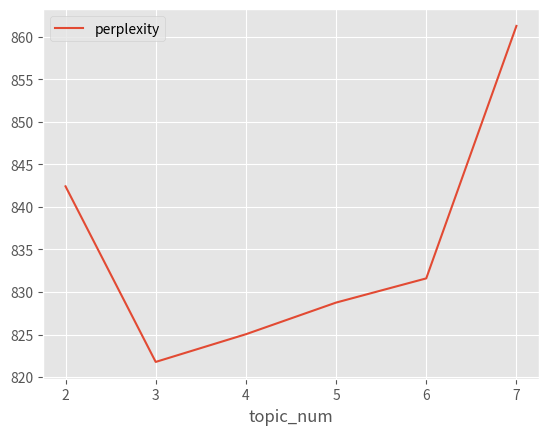

In [138]:
result.plot.line(x='topic_num', y='perplexity')

pmi：同一個 topic 裡的詞，有沒有常一起出現

越高 : 主題越「有意義、可解釋」

越低 : 主題很亂

<Axes: xlabel='topic_num'>

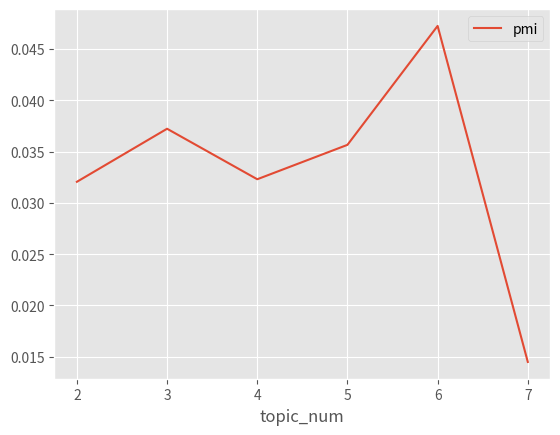

In [139]:
result.plot.line(x='topic_num', y='pmi')

綜合考量模型的解釋力與主題的語意一致性，雖然在 Perplexity 指標中 3 個主題的數值最低，代表對語料擬合最佳，但在 PMI 指標中，6 個主題表現相對較佳，顯示其主題內部詞彙的語意較集中、一致性較好。為兼顧模型效果與主題可解釋性，最終決定採用 6 個主題 作為 LDA 模型的主題數設定。

### 6.4 視覺化呈現

使用以主題數 6 的 Model 來做 LDAvis 的結果分析

In [140]:
best_model = LdaModel(
    corpus = corpus,
    num_topics = 6,
    id2word=dictionary,
    random_state = 1500,
    passes = 5 # 訓練次數
    )

2026-04-28 18:49:38,634 : INFO : using symmetric alpha at 0.16666666666666666
2026-04-28 18:49:38,636 : INFO : using symmetric eta at 0.16666666666666666
2026-04-28 18:49:38,637 : INFO : using serial LDA version on this node
2026-04-28 18:49:38,641 : INFO : running online (multi-pass) LDA training, 6 topics, 5 passes over the supplied corpus of 4936 documents, updating model once every 2000 documents, evaluating perplexity every 4936 documents, iterating 50x with a convergence threshold of 0.001000
2026-04-28 18:49:38,644 : INFO : PROGRESS: pass 0, at document #2000/4936
2026-04-28 18:49:39,569 : INFO : merging changes from 2000 documents into a model of 4936 documents
2026-04-28 18:49:39,571 : INFO : topic #0 (0.167): 0.037*"服務" + 0.028*"房間" + 0.022*"人員" + 0.014*"高雄" + 0.013*"親切" + 0.010*"乾淨" + 0.010*"早餐" + 0.009*"推薦" + 0.009*"很棒" + 0.008*"翰品"
2026-04-28 18:49:39,572 : INFO : topic #4 (0.167): 0.038*"服務" + 0.027*"人員" + 0.022*"高雄" + 0.021*"房間" + 0.020*"翰品" + 0.015*"親切" + 0.013*"住宿" + 0

先看看原本 10 個主題的LDA模型，可以看到每個主題都有字詞上的重疊

In [141]:
pyLDAvis.enable_notebook()
p = pyLDAvis.gensim_models.prepare(ldamodel, corpus, dictionary)
p

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.049692  0.004134       1        1  15.680443
2      0.086849 -0.027183       2        1  13.312707
4     -0.004450 -0.034513       3        1  11.837028
3      0.026136 -0.069445       4        1  11.105412
0      0.000560  0.042735       5        1  10.651449
5     -0.137061 -0.106025       6        1  10.170326
7     -0.011864  0.074710       7        1   8.031937
6     -0.010415  0.045639       8        1   6.820032
9      0.083650 -0.021379       9        1   6.695344
8     -0.083098  0.091326      10        1   5.695320, topic_info=     Term         Freq        Total Category  logprob  loglift
1227   康橋   619.000000   619.000000  Default  30.0000  30.0000
2598   青年   398.000000   398.000000  Default  29.0000  29.0000
234    方便  1435.000000  1435.000000  Default  28.0000  28.0000
2019   老闆   240.000000   240.000000  Default  27.0000  27.0000
2297   宵夜  1078.000000  1078.000000  Default  26.0000  26.0000
...   ...          ...          ...      ...      ...      ...
60     親切    50.546591  1453.959042  Topic10  -4.8937  -0.4936
279    很棒    43.837842   768.104223  Topic10  -5.0361   0.0021
36     房間    49.978099  2487.840798  Topic10  -4.9050  -1.0421
130    地點    39.698573   702.724799  Topic10  -5.1353  -0.0081
206    設施    36.742889   388.198053  Topic10  -5.2126   0.5080

[741 rows x 6 columns], token_table=      Topic      Freq Term
term                      
1685      4  0.034885   一个
1685      6  0.941889   一个
2084      2  0.969199   一出
1526      6  0.825447   一口
1526      8  0.058961   一口
...     ...       ...  ...
309       6  0.045924   齊全
309       7  0.199005   齊全
309       8  0.010205   齊全
309       9  0.005103   齊全
309      10  0.035719   齊全

[1948 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 5, 4, 1, 6, 8, 7, 10, 9])

接著觀察變成6個主題的，相對好很多:

In [141]:
# 調整後找出的最佳LDA模型
pyLDAvis.enable_notebook()
p = pyLDAvis.gensim_models.prepare(best_model, corpus, dictionary)
p

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4     -0.025785 -0.064864       1        1  28.823600
2      0.084800 -0.053047       2        1  27.317376
3      0.070447  0.095625       3        1  20.179287
0      0.033239 -0.175828       4        1  10.156777
1      0.134850  0.140802       5        1   7.774013
5     -0.297551  0.057313       6        1   5.748947, topic_info=     Term         Freq        Total Category  logprob  loglift
234    方便  1323.000000  1323.000000  Default  30.0000  30.0000
2160   翰品   790.000000   790.000000  Default  29.0000  29.0000
627    旅館   508.000000   508.000000  Default  28.0000  28.0000
560    朋友   490.000000   490.000000  Default  27.0000  27.0000
155    早餐  1795.000000  1795.000000  Default  26.0000  26.0000
...   ...          ...          ...      ...      ...      ...
472    地方    57.229126   472.628189   Topic6  -4.7789   0.7449
279    很棒    58.262416   751.178325   Topic6  -4.7610   0.2995
15     員工    47.236867   289.186882   Topic6  -4.9708   1.0443
41     服務    48.457101  4012.574391   Topic6  -4.9453  -1.5604
6      住宿    45.919234   903.121317   Topic6  -4.9991  -0.1228

[456 rows x 6 columns], token_table=      Topic      Freq Term
term                      
1685      3  0.972810   一个
2084      6  0.910571   一出
2623      3  0.984306  一分鐘
1856      5  0.893210  一大床
1720      2  0.160662  一家人
...     ...       ...  ...
2012      1  0.915855  鹽埕區
2012      4  0.065418  鹽埕區
1786      3  0.960321   麵條
1522      1  0.978593   龍蝦
1522      4  0.020821   龍蝦

[972 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 3, 4, 1, 2, 6])

根據觀察可以將上述LDA 分析結果統整如下：

Topic 1 整體住宿體驗與服務評價

Topic 2 早餐與服務品質

Topic 3 房間與清潔品質

Topic 4 住宿設施與附加服務

Topic 5 旅遊與住宿情境（行程/地區）

Topic 6 地點與交通便利性

結論：有部分重疊，每個主題的Terms較難分出差別

In [142]:
pyLDAvis.save_html(p, "lda_tripadvisor.html")

### 6.5 GuidedLDA

前面的方法是模型自己學出來的結果，這次改用需要人工介入的GuidedLDA，提供Seed Words，可預定義特定主題

topic 0: 房間設施

topic 1: 服務與接待

topic 2: 餐飲

topic 3: 地點與交通

topic 4: 旅遊體驗

topic 5: 環境品質

In [143]:
word2id = dictionary.token2id

In [144]:
# 根據飯店評論常見主題設定種子詞
seed_topic_list = [
    ["房間", "床", "浴室", "空間", "設備"],      # 房間設施
    ["服務", "態度", "人員", "櫃台", "親切"],    # 服務與接待
    ["早餐", "餐廳", "飲料", "食物", "菜色"],    # 餐飲
    ["地點", "交通", "位置", "捷運", "車站"],    # 地點與交通
    ["價格", "便宜", "值得", "划算", "推薦"],    # 旅遊體驗
    ["乾淨", "整潔", "舒適", "安靜", "衛生"],    # 環境品質
]

In [145]:
# 將 seed words 對應到 dictionary 的 token id
# 有些詞可能因 filter_extremes 被移除,需要 skip
seed_topics = {}
missing = []
for t_id, st in enumerate(seed_topic_list):
    for word in st:
        if word in word2id:
            seed_topics[word2id[word]] = t_id
        else:
            missing.append(word)
print(f"有效 seed words: {len(seed_topics)} 個")
if missing:
    print(f"這些詞不在 dictionary (可能被 filter 移除): {missing}")

有效 seed words: 29 個
這些詞不在 dictionary (可能被 filter 移除): ['床']


In [146]:
# (此格跟上格作用相同,保留原範本結構)
seed_topics = {}
for t_id, st in enumerate(seed_topic_list):
    for word in st:
        if word in word2id:
            seed_topics[word2id[word]] = t_id

In [147]:
# guidedlda 需要 DTM 格式作為 input，因此這邊利用 corpus2dense() 方法進行轉換
X = corpus2dense(corpus, len(dictionary), len(corpus)).T.astype(np.int64)

In [148]:
model = guidedlda.GuidedLDA(n_topics=6, n_iter=100, random_state=7, refresh=20)
model.fit(X, seed_topics=seed_topics, seed_confidence=1)

2026-04-28 18:50:13,652 : INFO : n_documents: 4936
2026-04-28 18:50:13,653 : INFO : vocab_size: 2813
2026-04-28 18:50:13,653 : INFO : n_words: 118434
2026-04-28 18:50:13,654 : INFO : n_topics: 6
2026-04-28 18:50:13,655 : INFO : n_iter: 100


2026-04-28 18:50:14,255 : INFO : <0> log likelihood: -1110047
2026-04-28 18:50:14,427 : INFO : <20> log likelihood: -852515
2026-04-28 18:50:14,596 : INFO : <40> log likelihood: -837194
2026-04-28 18:50:14,760 : INFO : <60> log likelihood: -831669
2026-04-28 18:50:14,924 : INFO : <80> log likelihood: -827089
2026-04-28 18:50:15,076 : INFO : <99> log likelihood: -824800


In [149]:
# 整理／顯示主題模型結果
n_top_words = 10
topic_word = model.topic_word_
# 取得corpus全部的詞彙表
vocab = tuple(dictionary.token2id.keys())

for i, topic_dist in enumerate(topic_word):
    # 依照詞語機率從小到大排序，找出每個主題的前十個關鍵詞
    topic_words = np.array(vocab)[np.argsort(topic_dist)][: -(n_top_words + 1) : -1]
    print("Topic {}: {}".format(i, " ".join(topic_words)))
    

doc_topic = model.doc_topic_ # 文件-主題 分佈
term_freq = tuple(dictionary.cfs.values()) # 每個詞在整個語料中出現的總次數
doc_len = [sum(v for k, v in doc) for doc in corpus] # 每篇文章的長度

## LDAvis
pyLDAvis.enable_notebook()
p = pyLDAvis.prepare(topic_word, doc_topic, doc_len, vocab = vocab, term_frequency = term_freq)
p

Topic 0: 房間 服務 人員 不錯 浴室 使用 早餐 漢來 空間 時間
Topic 1: 服務 人員 高雄 親切 房間 翰品 乾淨 早餐 態度 舒適
Topic 2: 服務 房間 早餐 免費 位置 很棒 餐廳 高雄 工作 清潔
Topic 3: 方便 服務 高雄 交通 房間 附近 捷運站 早餐 人員 乾淨
Topic 4: 高雄 旅館 朋友 翰品 旅悅 青年 親切 參加 歷史 環境
Topic 5: 服務 房間 乾淨 早餐 舒適 人員 宵夜 免費 好吃 親切


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.066543  0.014917       1        1  24.196509
3      0.047587  0.155451       2        1  17.116655
2     -0.106700  0.070287       3        1  16.324387
0     -0.236300 -0.159433       4        1  15.670514
5      0.014879  0.106389       5        1  15.414507
4      0.213992 -0.187612       6        1  11.277428, topic_info=    Term         Freq        Total Category  logprob  loglift
234   方便  1340.000000  1340.000000  Default  30.0000  30.0000
304   交通   830.000000   830.000000  Default  29.0000  29.0000
36    房間  2903.000000  2903.000000  Default  28.0000  28.0000
73    高雄  2387.000000  2387.000000  Default  27.0000  27.0000
60    親切  1569.000000  1569.000000  Default  26.0000  26.0000
..   ...          ...          ...      ...      ...      ...
39    旅行    69.953326   244.705864   Topic6  -5.2519   0.9301
6     住宿    81.943612   964.395361   Topic6  -5.0937  -0.2831
41    服務    95.932278  4302.609696   Topic6  -4.9361  -1.6210
338   舒適    78.946040  1256.936092   Topic6  -5.1310  -0.5853
245   舒服    70.952516   491.346436   Topic6  -5.2377   0.2472

[483 rows x 6 columns], token_table=      Topic      Freq Term
term                      
1561      1  0.993750   一一
1685      6  0.996825   一个
2370      1  0.998280   一同
952       1  0.158064   一樓
952       2  0.140501   一樓
...     ...       ...  ...
224       2  0.177750   點心
224       3  0.017342   點心
224       4  0.073701   點心
224       5  0.533251   點心
2453      2  0.994276  龍蝦餐

[921 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 4, 3, 1, 6, 5])

根據輸出的各主題 top words,可以觀察是否符合預設的 6 大主題
(房間設施 / 服務 / 餐飲 / 地點 / 價格 / 環境品質)。

在價格主題中，無法辨認它突出的特色，因此將seed words 改成五組,希望讓模型更穩定地收斂到這些語意方向。

In [150]:
# topic 0: 房間設施
# topic 1: 服務與接待
# topic 2: 餐飲
# topic 3: 地點與交通
# topic 4: 旅遊體驗
# topic 5: 環境品質

In [151]:
seed_topic_list = [
    ["房間", "床", "浴室", "空間", "設備", "房型", "浴缸", "交誼廳"],      # 房間設施
    ["服務", "態度", "人員", "櫃台", "親切", "櫃檯", "友好", "老闆娘"],    # 服務與接待
    ["早餐", "餐廳", "飲料", "食物", "菜色", "好吃", "宵夜", "餐點", "晚餐", "啤酒"],    # 餐飲
    ["地點", "交通", "位置", "捷運", "車站", "捷運站","高雄", "愛河", "便利", "駁二", "走路", "火車站", "夜市"],    # 地點與交通
    ["價格", "便宜", "值得", "划算", "推薦", "體驗", "行程", "購物"],    # 旅遊體驗
    ["乾淨", "整潔", "舒適", "安靜", "衛生", "清潔", "舒適度"],    # 環境品質
]
# 重新建 seed_topics
seed_topics = {}
for t_id, st in enumerate(seed_topic_list):
    for word in st:
        if word in word2id:
            seed_topics[word2id[word]] = t_id

In [152]:
model = guidedlda.GuidedLDA(n_topics=6, n_iter=100, random_state=7, refresh=20)
model.fit(X, seed_topics=seed_topics, seed_confidence=1)

2026-04-28 18:50:24,669 : INFO : n_documents: 4936
2026-04-28 18:50:24,669 : INFO : vocab_size: 2813
2026-04-28 18:50:24,670 : INFO : n_words: 118434
2026-04-28 18:50:24,671 : INFO : n_topics: 6
2026-04-28 18:50:24,671 : INFO : n_iter: 100
2026-04-28 18:50:25,255 : INFO : <0> log likelihood: -1088982
2026-04-28 18:50:25,428 : INFO : <20> log likelihood: -854779
2026-04-28 18:50:25,585 : INFO : <40> log likelihood: -838076
2026-04-28 18:50:25,740 : INFO : <60> log likelihood: -829765
2026-04-28 18:50:25,900 : INFO : <80> log likelihood: -825235
2026-04-28 18:50:26,052 : INFO : <99> log likelihood: -823566


In [153]:
n_top_words = 10
topic_word = model.topic_word_

for i, topic_dist in enumerate(topic_word):
    topic_words = np.array(vocab)[np.argsort(topic_dist)][: -(n_top_words + 1) : -1]
    print("Topic {}: {}".format(i, " ".join(topic_words)))
    

doc_topic = model.doc_topic_
term_freq = tuple(dictionary.cfs.values())
doc_len = [sum(v for k, v in doc) for doc in corpus]

## LDAvis
pyLDAvis.enable_notebook()
p = pyLDAvis.prepare(topic_word, doc_topic, doc_len, vocab = vocab, term_frequency = term_freq)
p

Topic 0: 房間 人員 服務 不錯 浴室 早餐 使用 漢來 時間 空間
Topic 1: 服務 人員 親切 高雄 房間 翰品 乾淨 舒適 住宿 態度
Topic 2: 早餐 服務 宵夜 房間 好吃 乾淨 人員 康橋 高雄 免費
Topic 3: 服務 方便 高雄 交通 房間 人員 附近 乾淨 親切 捷運站
Topic 4: 高雄 旅館 朋友 旅悅 青年 歷史 老闆娘 親切 喜歡 熱情
Topic 5: 服務 房間 早餐 清潔 衛生 位置 免費 乾淨 很棒 高雄


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1      0.027897  0.066162       1        1  24.177886
3     -0.041368  0.141900       2        1  21.413180
5     -0.092867 -0.018995       3        1  17.225292
0     -0.115459 -0.283905       4        1  14.748533
2     -0.103753  0.143008       5        1  13.075792
4      0.325550 -0.048170       6        1   9.359317, topic_info=     Term         Freq        Total Category  logprob  loglift
2297   宵夜   806.000000   806.000000  Default  30.0000  30.0000
155    早餐  1809.000000  1809.000000  Default  29.0000  29.0000
41     服務  4302.000000  4302.000000  Default  28.0000  28.0000
234    方便  1340.000000  1340.000000  Default  27.0000  27.0000
131    好吃   791.000000   791.000000  Default  26.0000  26.0000
...   ...          ...          ...      ...      ...      ...
245    舒服    70.981078   491.355181   Topic6  -5.0509   0.4340
2160   翰品    75.979041  1002.079203   Topic6  -4.9829  -0.2106
71     體驗    58.985965   237.708162   Topic6  -5.2360   0.9751
399    晚上    64.983521   690.020265   Topic6  -5.1392   0.0062
150    推薦    61.984743   875.516476   Topic6  -5.1864  -0.2791

[474 rows x 6 columns], token_table=      Topic      Freq Term
term                      
1561      1  0.993719   一一
2370      1  0.998248   一同
921       1  0.060536   一張
921       4  0.908042   一張
921       6  0.030268   一張
...     ...       ...  ...
2183      3  0.030116   鹽埕
2183      6  0.105405   鹽埕
2012      1  0.140484  鹽埕區
2012      2  0.842905  鹽埕區
2012      6  0.017561  鹽埕區

[865 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 4, 6, 1, 3, 5])

從 PyLDAVis 的視覺化結果來看，各主題間大致有明顯區隔，且高頻詞與種子詞匹配良好，顯示模型已能穩定辨識語料中的潛在主題結構

沒辦法分得很開的原因，比如說評論在評價服務的同時，可能會包含餐點好吃，所以整個評論是包含2種主題的，才導致沒辦法分得很乾淨

### 6.6 主題分佈的應用，搭配其他文章資訊 (LDA)

In [154]:
# 取得主題分佈
topics_doc = best_model.get_document_topics(corpus)

In [155]:
topics_doc[0]

[(4, 0.8731821), (5, 0.11995677)]

#### 6.6.1 將 LDA 模型推論後的每篇文件的 主題分布（也就是 𝜃）轉換成一個 NumPy 矩陣（array）

In [156]:
# 把 gensim 的稀疏表示法轉成稀疏矩陣
m_theta = corpus2csc(topics_doc).T.toarray() # 倒置讓shape變為(num_docs, num_topics)
m_theta

array([[0.        , 0.        , 0.        , 0.        , 0.87317455,
        0.11996432],
       [0.        , 0.22217473, 0.        , 0.14872269, 0.61470389,
        0.        ],
       [0.        , 0.15068161, 0.14930865, 0.26204482, 0.43400121,
        0.        ],
       ...,
       [0.66289246, 0.        , 0.        , 0.21145533, 0.06863413,
        0.04986709],
       [0.60153544, 0.        , 0.11046654, 0.        , 0.16361034,
        0.12001085],
       [0.17284945, 0.06412059, 0.11948908, 0.16906798, 0.33826473,
        0.13620819]])

In [157]:
# 將主題的機率分布轉換成主題標籤
sma_data['topic_label'] = m_theta.argmax(axis=1) + 1

#### 6.6.2 統計各個主題的數量

In [158]:
sma_data['topic_label'].value_counts()

topic_label
3    1752
5    1613
4     666
1     459
2     223
6     223
Name: count, dtype: int64

In [159]:
sma_data.head()

,content,artUrl,hotel_class,date_posted,words,lexicon_topic,topic_scores,topic_label
0,愛上高雄漢來飯店的原因這次帶著喜歡庫洛米的入住高雄漢來飯店的三麗鷗主題房我們選擇的是美樂蒂和...,all_0,5star,2024年11月,"[愛上, 高雄, 漢來, 原因, 喜歡, 庫洛米, 高雄, 漢來, 三麗鷗, 主題房, 美樂...",服務與接待,"{'房間設施': 2, '服務與接待': 10, '餐飲體驗': 0, '地點交通': 1,...",5
1,復活節假期帶老婆到高雄看月天演唱會住了晚漢來大飯店原因是因為有主題房老婆是超級酒店離地鐵站並...,all_1,5star,2024年8月,"[復活節, 假期, 老婆, 高雄, 看月天, 演唱會, 晚漢來, 原因, 主題房, 老婆, ...",房間設施,"{'房間設施': 3, '服務與接待': 0, '餐飲體驗': 0, '地點交通': 1, ...",5
2,大概是全世界最用心的三麗鷗主題房大家好我是膚淺喜歡被讚美的丹丹這篇要介紹的是高雄漢來大飯店三...,all_2,5star,2023年12月,"[全世界, 用心, 三麗鷗, 主題房, 膚淺, 喜歡, 讚美, 丹丹, 這篇要, 介紹, 高...",房間設施,"{'房間設施': 13, '服務與接待': 8, '餐飲體驗': 5, '地點交通': 2,...",5
3,若活動範圍在南高雄算是可以選擇的酒店之一離捷運遠需利用計程車過去每年農曆春節常常會住這邊一晚...,all_3,5star,2023年5月,"[活動, 範圍, 高雄, 算是, 之一離, 捷運, 遠需, 利用, 計程車, 過去, 每年,...",地點交通,"{'房間設施': 1, '服務與接待': 1, '餐飲體驗': 2, '地點交通': 5, ...",4
4,我覺得大廳環境不錯但走進去沒人理我好幾分鐘不知道哪裡入住最後是我自己問才知道是找有點久湯裡面...,all_4,5star,2023年4月,"[大廳, 環境, 不錯, 走進去, 沒人理, 幾分鐘, 知道, 最後, 問才, 知道, 久湯...",環境與清潔,"{'房間設施': 1, '服務與接待': 0, '餐飲體驗': 2, '地點交通': 0, ...",4


Topic 1 整體住宿體驗與服務評價

Topic 2 早餐與服務品質

Topic 3 房間與清潔品質

Topic 4 住宿設施與附加服務

Topic 5 旅遊與住宿情境（行程/地區）

Topic 6 地點與交通便利性

#### 6.6.3 查看每個飯店星級下的主題分布

In [160]:
sma_data.groupby('hotel_class')['topic_label'].value_counts(normalize=True)

hotel_class  topic_label
2star        6              0.385263
             1              0.231579
             4              0.162105
             5              0.107368
             3              0.080000
             2              0.033684
3star        3              0.765105
             4              0.080109
             5              0.063815
             1              0.047522
             2              0.040054
             6              0.003394
4star        5              0.558410
             3              0.207949
             1              0.104376
             4              0.065436
             2              0.050181
             6              0.013649
5star        4              0.619718
             5              0.154930
             3              0.138833
             2              0.046278
             1              0.038229
             6              0.002012
Name: proportion, dtype: float64

In [161]:
hotel_topic = sma_data.groupby('hotel_class')['topic_label'].value_counts(normalize=True).unstack()
hotel_topic

topic_label,1,2,3,4,5,6
hotel_class,,,,,,
2star,0.231579,0.033684,0.080000,0.162105,0.107368,0.385263
3star,0.047522,0.040054,0.765105,0.080109,0.063815,0.003394
4star,0.104376,0.050181,0.207949,0.065436,0.558410,0.013649
5star,0.038229,0.046278,0.138833,0.619718,0.154930,0.002012


#### 6.6.4 視覺化呈現各星級飯店的主題分布

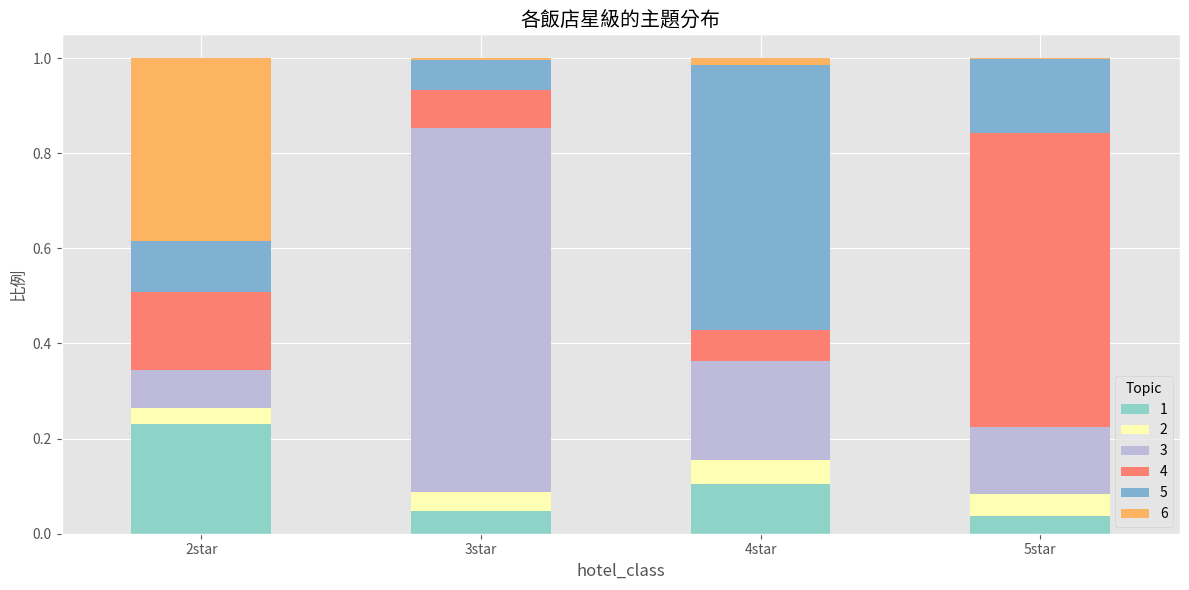

In [162]:
fig, ax = plt.subplots(figsize=(12, 6))
hotel_topic.plot.bar(ax=ax, stacked=True, color=plt.cm.Set3.colors)
ax.legend(loc='lower right', title='Topic')
ax.set_title("各飯店星級的主題分布")
ax.set_ylabel("比例")
plt.xticks(rotation=0)
plt.tight_layout()

Topic 1 整體住宿體驗與服務評價

Topic 2 早餐與服務品質

Topic 3 房間與清潔品質

Topic 4 住宿設施與附加服務

Topic 5 旅遊與住宿情境（行程/地區）

Topic 6 地點與交通便利性

觀察重點:
- 哪些主題在低星級飯店 (2 星) 比例特別高 → 可能是地點與交通便利性
- 哪些主題在高星級飯店 (5 星) 比例特別高 → 可能是關於住宿設施與附加服務